# Hawkes-process JSCC — vrai train de spikes en entrée/sortie, N aléatoire

Suite de `point_process_jscc.ipynb`, même énoncé (`student_project_point_process_jscc.pdf`),
même canal à jitter gaussien, même contrainte `N_X = N_S`, `R = 1`. Version SNN "au sens
classique" du terme, après discussion sur l'architecture :

1. **La source** : un processus de Hawkes à noyau exponentiel, observé sur une fenêtre `Ts`
   **fixe**, sans aucun nombre d'événements imposé a priori. Un vrai point process a un nombre
   d'événements **aléatoire** sur une fenêtre fixe — la contrainte `N_X = N_S` du PDF ne doit donc
   pas être une propriété de la source, mais une contrainte **structurelle** imposée par
   l'encodeur, bloc par bloc.
2. **L'entrée/la sortie du SNN sont un vrai train de spikes** : un raster binaire sur `T_bins`
   pas de temps discrets fixes, pas des features analogiques dérivées par événement. Toujours une
   seule couche cachée LIF, feed-forward.
3. **`N_X = N_S` est garanti par construction (top-N par rang)**, pas par une pénalité de loss :
   vraie pour tout poids, avant même l'entraînement.
4. **La distorsion suit fidèlement l'éq. 7-8 du PDF** (`(1/N)Σ(T_i-T̂_i)²`, appariée par indice,
   continue) plutôt qu'une MSE bin-à-bin sur le raster -- cf. markdown "Distorsion fidèle au PDF".

## Deux bugs de gradient trouvés et corrigés en cours de route

En creusant pourquoi l'encodeur n'apprenait presque rien, deux ruptures du graphe de calcul :

- **Le canal coupait tout le gradient vers l'encodeur** (`r_channel.requires_grad` était `False`,
  `encoder.net.syn.weight.grad` était `None`) -- `.bool()`, `.floor()`, `scatter_` avec une valeur
  constante ne transportent aucun gradient. Corrigé par straight-through (exact en avant, noyau
  gaussien différentiable en arrière). Cf. markdown "Canal".
- **Le seuil `theta` de chaque neurone LIF ne recevait aucun gradient** (`theta.grad` valait
  `None`) une fois le readout basé sur `u` plutôt que `s` : `theta` n'influence que `s`, détaché
  dans le terme de reset. Corrigé en ne détachant plus `s` (1re approximation SuperSpike). Cf.
  markdown "Le SNN simple".

**Ces corrections ne suffisent pas à elles seules à obtenir un système bien entraîné** : même
après les deux, `decoder` et `jscc` restent nettement pires que `uncoded` sur le budget
d'entraînement testé. Le PDF anticipe explicitement ce risque ("Optimization issue: be careful
about possible optimization issues") -- cf. "Limites" en fin de notebook pour le détail des
causes probables (choisi ici comme constat de recherche assumé, pas une confusion cachée).

## Limite assumée : quantification temporelle et collisions de bins

Revenir à un raster à `T_bins` fixes réintroduit la discrétisation qu'une version antérieure de
ce notebook évitait délibérément (les temps `T_i` du PDF sont continus). Conséquence mesurée
empiriquement : la source Hawkes a une proportion non négligeable d'écarts très petits, donc
**même à `T_bins=1024`, une fraction significative de blocs a au moins deux événements dans le
même bin** (collision, fusionnés en un seul `1`, perte d'information). `T_bins=128` est un
compromis retenu ici, pas un point où le problème disparaît.

In [1]:
from __future__ import annotations  # `X | None` en annotation, aussi sous Python 3.9

from dataclasses import dataclass, replace
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.set_num_threads(4)
DEVICE = "cpu"


@dataclass
class Config:
    # ---------------- source (Hawkes, point process réel, N aléatoire) --------
    Ts: float = 1.0             # durée du bloc source (fenêtre FIXE). Tc = Ts, R = 1.
    mean_gap: float = 1.0 / 9.0 # échelle de temps de la source (mu, alpha, beta et
                                 # sigma_J en dépendent). N_S par bloc est ALÉATOIRE,
                                 # ce champ ne fixe qu'un taux moyen, pas un compte.
    hawkes_branching: float = 0.5   # n = alpha/beta dans (0,1) : part du taux qui
                                     # vient de l'auto-excitation. n->0 : quasi-Poisson.
    hawkes_decay: float = 1.0       # durée de vie de l'excitation, unités de gap moyen.
    n_burn: int = 100           # événements de rodage avant d'enregistrer (stationnarité).
    max_events_cap: int = 400   # garde-fou technique (branching quasi-critique) --
                                 # jamais atteint en pratique dans le grid étudié.

    # ---------------- représentation : raster binaire (le "temps" du SNN) -----
    T_bins: int = 128           # nombre de bins temporels fixes. Compromis
                                 # fidélité/coût -- cf. markdown, collisions non nulles
                                 # même à T_bins bien plus grand.

    # ---------------- canal ---------------------------------------------------
    sigma_J: float = 0.03       # écart-type du jitter (unités de Ts).

    # ---------------- réseau (SNN) ---------------------------------------------
    hidden: int = 64            # largeur de l'unique couche cachée LIF.
    spike_alpha: float = 2.0    # pente du surrogate arctan (spikes LIF et top-N).

    # ---------------- optimisation ------------------------------------------------
    steps: int = 3000
    batch: int = 256
    lr: float = 3e-4            # lr=3e-3 (valeur initiale) fait diverger cette loss :
                                 # bonne au début (~step 150), puis explose vers un
                                 # plateau 5-15x pire. 3e-4 reste stable (cf. markdown
                                 # "Distorsion fidèle au PDF").
    seed: int = 0
    eval_batch: int = 8000

    @property
    def Tc(self) -> float:
        return self.Ts                      # R = Ts/Tc = 1

    @property
    def bin_width(self) -> float:
        return self.Ts / self.T_bins


CFG = Config()
print(CFG)
print(f"bin_width = {CFG.bin_width:.5f}  (mean_gap = {CFG.mean_gap:.4f})")

Config(Ts=1.0, mean_gap=0.1111111111111111, hawkes_branching=0.5, hawkes_decay=1.0, n_burn=100, max_events_cap=400, T_bins=128, sigma_J=0.03, hidden=64, spike_alpha=2.0, steps=3000, batch=256, lr=0.0003, seed=0, eval_batch=8000)
bin_width = 0.00781  (mean_gap = 0.1111)


## Constantes d'exécution

In [2]:
BRANCHING_GRID = [0.0, 0.3, 0.6, 0.85]   # 0.0 = quasi-Poisson, contrôle sans mémoire
SIGMA_RATIO = 0.4                         # sigma_J / mean_gap, fixe pour tout le sweep
MODES = ["uncoded", "decoder", "jscc"]

RASTER_N_BLOCKS, RASTER_SEED = 16, 3
GAPMAP_N_BLOCKS, GAPMAP_SEED = 1500, 4242
REALISATION_BLOCKS, REALISATION_SEED = [0, 1, 2, 3, 4], 7   # plusieurs blocs, N_S variable

## Conventions de tracé

Même palette et même fonction `style` que `point_process_jscc.ipynb` (elle-même alignée sur
`temporal-jscc/scripts/visualize.py`), pour que les trois notebooks se lisent ensemble.

In [3]:
C_UNCODED, C_DECODER, C_JSCC = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#8a8983", "#e4e3df", "#fcfcfb"
MODE_STYLE = {"uncoded": (C_UNCODED, "o"), "decoder": (C_DECODER, "s"),
              "jscc": (C_JSCC, "^")}


def style(ax, xlabel, ylabel, title, subtitle=None):
    ax.set_facecolor(SURFACE)
    ax.grid(True, color=GRID, lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(GRID)
    ax.tick_params(colors=INK2, labelsize=9, length=3, color=GRID)
    ax.set_xlabel(xlabel, color=INK2, fontsize=10)
    ax.set_ylabel(ylabel, color=INK2, fontsize=10)
    ax.set_title(title, color=INK, fontsize=12, loc="left", pad=26 if subtitle else 8)
    if subtitle:
        ax.text(0.0, 1.02, subtitle, transform=ax.transAxes, color=MUTED,
                fontsize=9, va="bottom")


def legend(ax, loc="upper left"):
    leg = ax.legend(frameon=False, fontsize=9, loc=loc)
    for t in leg.get_texts():
        t.set_color(INK2)

## Source : Hawkes à noyau exponentiel, fenêtre fixe, N aléatoire

```
lambda(t) = mu + alpha * sum_{T_i < t} exp(-beta * (t - T_i))
```

chaque événement augmente temporairement l'intensité, donc les points arrivent en rafales suivies
de silences. `mu`, `alpha`, `beta` sont dérivés de `mean_gap`, `hawkes_branching`
(`n = alpha/beta`) et `hawkes_decay`, pour que le taux moyen à l'équilibre reste `1/mean_gap`.
Simulé exactement par amincissement de Ogata (1981), avec un rodage pour démarrer en régime
stationnaire.

**Différence avec une version antérieure de ce notebook** : ici, on n'accumule pas jusqu'à un
nombre d'événements fixé puis on ne renormalise pas le bloc. On simule sur `[0, Ts)` (fenêtre
fixe) et on garde tous les événements qui y tombent, quel que soit leur nombre — un vrai point
process. Le résultat est directement rastérisé : `r_source ∈ {0,1}^{T_bins}`, `1` si un événement
tombe dans ce bin. `N_S = r_source.sum()` est une **conséquence** du tirage, jamais un paramètre.

In [4]:
def _hawkes_window_record(mu, alpha, beta, n_burn, Ts, max_events, rng):
    """Un bloc de Hawkes par amincissement de Ogata (1981), sur une fenêtre de
    durée Ts FIXE -- N_S est une conséquence du tirage, pas un paramètre fixé
    a priori. `n_burn` événements sont simulés et jetés avant d'enregistrer quoi
    que ce soit, pour démarrer en régime stationnaire plutôt qu'avec
    `excess = 0`. On s'arrête dès que le prochain temps candidat dépasse Ts :
    comme ce temps ne fait que croître au fil de l'amincissement, aucun
    événement accepté ne pourra plus retomber sous Ts ensuite. `max_events` est
    un garde-fou technique (branching quasi-critique), pas une contrainte sur N.
    """
    t, excess = 0.0, 0.0
    for _ in range(n_burn):
        M = mu + excess
        tau = rng.exponential(1.0 / M)
        excess *= np.exp(-beta * tau)
        t += tau
        if rng.random() <= (mu + excess) / M:
            excess += alpha
    t0 = t

    times = []
    while len(times) < max_events:
        M = mu + excess
        tau = rng.exponential(1.0 / M)
        excess *= np.exp(-beta * tau)
        t += tau
        t_rel = t - t0
        if t_rel >= Ts:
            break
        if rng.random() <= (mu + excess) / M:
            times.append(t_rel)
            excess += alpha
    return np.array(times)


def sample_source(cfg: Config, batch: int, rng: np.random.Generator):
    """-> (r_source (batch, T_bins), n_raw (batch,)).

    r_source : raster binaire, 1 si un événement tombe dans ce bin. n_raw : le
    nombre d'événements BRUTS simulés (avant rastérisation) -- sert uniquement
    au diagnostic de collision (n_raw != r_source.sum(dim=1) quand deux
    événements sont tombés dans le même bin).
    """
    lam0 = 1.0 / cfg.mean_gap
    n = float(cfg.hawkes_branching)
    beta = 1.0 / (cfg.hawkes_decay * cfg.mean_gap)
    alpha = n * beta
    mu = lam0 * (1.0 - n)
    r = torch.zeros(batch, cfg.T_bins, dtype=torch.float32, device=DEVICE)
    n_raw = np.zeros(batch, dtype=np.int64)
    for b in range(batch):
        times = _hawkes_window_record(mu, alpha, beta, cfg.n_burn, cfg.Ts,
                                       cfg.max_events_cap, rng)
        n_raw[b] = len(times)
        if len(times):
            idx = np.minimum((times / cfg.bin_width).astype(np.int64), cfg.T_bins - 1)
            r[b, idx] = 1.0
    return r, n_raw


def raster_to_times(r: torch.Tensor, cfg: Config):
    """(B,T_bins) raster -> liste de B arrays de temps (centres de bin),
    croissants par construction (ordre des indices de bin). Sert uniquement
    aux diagnostics/figures, pas au chemin d'entraînement."""
    centers = (torch.arange(cfg.T_bins, dtype=torch.float32) + 0.5) * cfg.bin_width
    return [centers[row.bool()].numpy() for row in r]


def source_stats(cfg: Config, batch: int = 4000, seed: int = 12345) -> dict:
    r, n_raw = sample_source(cfg, batch, np.random.default_rng(seed))
    n_s = r.sum(dim=1).numpy()
    return {"mean_n_s": float(n_s.mean()), "std_n_s": float(n_s.std()),
            "frac_source_collision": float((n_raw != n_s).mean()),
            "frac_capped": float((n_raw >= cfg.max_events_cap).mean())}


for b in BRANCHING_GRID:
    print(f"branching={b:4.2f}  {source_stats(replace(CFG, hawkes_branching=b))}")

branching=0.00  {'mean_n_s': 8.687749862670898, 'std_n_s': 2.8192641735076904, 'frac_source_collision': 0.26675, 'frac_capped': 0.0}
branching=0.30  {'mean_n_s': 8.967499732971191, 'std_n_s': 3.8187620639801025, 'frac_source_collision': 0.341, 'frac_capped': 0.0}


branching=0.60  {'mean_n_s': 10.148750305175781, 'std_n_s': 6.639286518096924, 'frac_source_collision': 0.4325, 'frac_capped': 0.0}


branching=0.85  {'mean_n_s': 17.364500045776367, 'std_n_s': 16.575769424438477, 'frac_source_collision': 0.57775, 'frac_capped': 0.0}


`mean_n_s` croît un peu avec `branching` (l'auto-excitation pousse plus d'événements dans la
fenêtre), et surtout `frac_source_collision` (fraction de blocs où au moins deux événements sont
tombés dans le même bin) augmente nettement avec `branching` : c'est la signature des rafales —
des écarts intra-rafale plus petits que `bin_width`, donc plus de collisions. `frac_capped` doit
rester à 0 : sinon `max_events_cap` est trop bas pour ce régime.

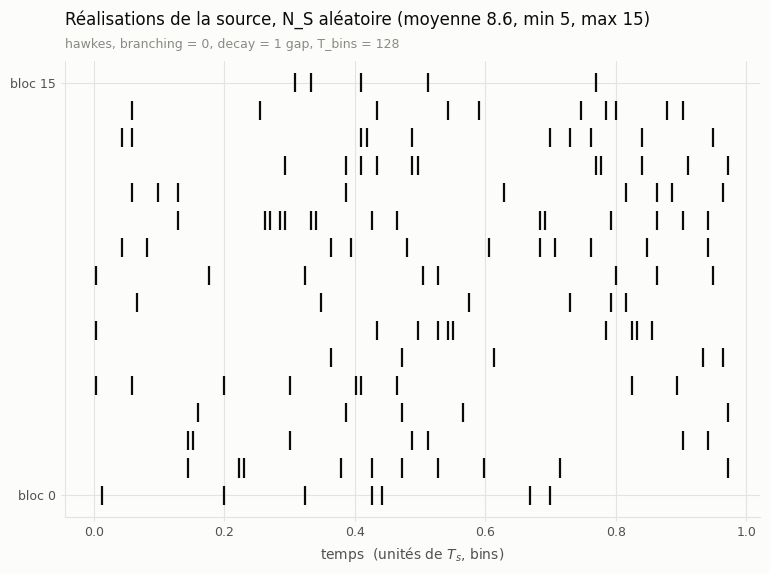

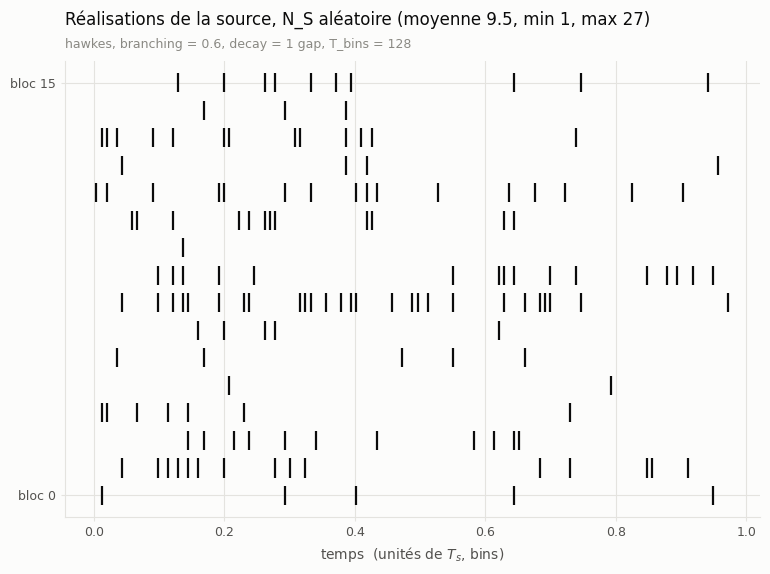

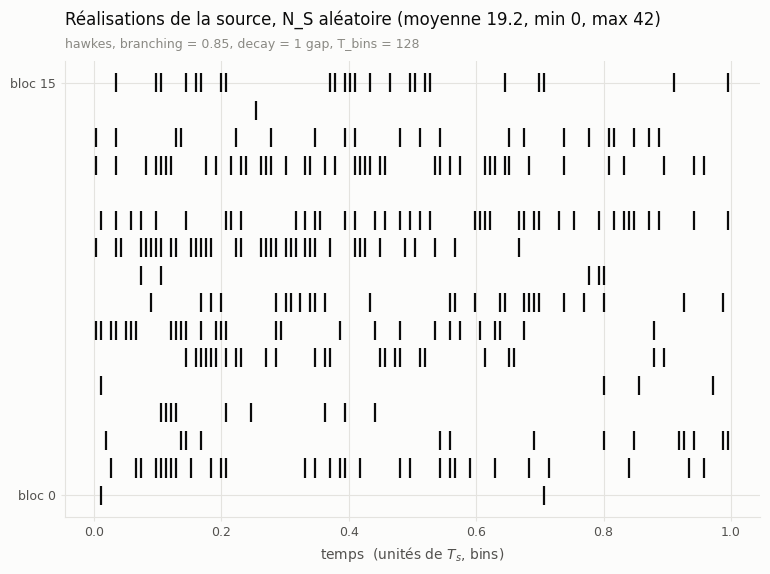

In [5]:
def fig_source_raster(cfg: Config, n_blocks: int = 16, seed: int = 3):
    r, _ = sample_source(cfg, n_blocks, np.random.default_rng(seed))
    times = raster_to_times(r, cfg)
    n_s = [len(t) for t in times]
    fig, ax = plt.subplots(figsize=(7.8, 0.24 * n_blocks + 2.0), facecolor=SURFACE)
    ax.eventplot(times, colors=INK, lineoffsets=np.arange(n_blocks),
                 linelengths=0.7, linewidths=1.6, zorder=5)
    ax.set_ylim(-0.8, n_blocks - 0.2)
    ax.set_yticks([0, n_blocks - 1])
    ax.set_yticklabels(["bloc 0", f"bloc {n_blocks - 1}"])
    style(ax, "temps  (unités de $T_s$, bins)", "",
          f"Réalisations de la source, N_S aléatoire (moyenne {np.mean(n_s):.1f}, "
          f"min {min(n_s)}, max {max(n_s)})",
          f"hawkes, branching = {cfg.hawkes_branching:g}, decay = {cfg.hawkes_decay:g} gap, "
          f"T_bins = {cfg.T_bins}")
    fig.tight_layout()
    return fig


for b in (0.0, 0.6, 0.85):
    fig_source_raster(replace(CFG, hawkes_branching=b), n_blocks=RASTER_N_BLOCKS,
                      seed=RASTER_SEED)
    plt.show()

## Canal

Jitter gaussien additif, appliqué à un raster de spikes plutôt qu'à des temps continus.

**Bug trouvé et corrigé : le canal coupait tout le gradient vers l'encodeur.** La version initiale
construisait le raster de sortie via `.bool()`, `.floor()`, `.long()` et `scatter_` avec une
valeur *constante* (`torch.ones_like(r)`, pas `r` lui-même) -- aucune de ces opérations ne
transporte de gradient. Résultat vérifié : `r_channel.requires_grad` était `False`, et
`encoder.net.syn.weight.grad` était `None` après `backward()` -- l'encodeur ne recevait
**littéralement aucun signal d'erreur**, peu importe combien on l'entraînait. Ce n'est pas un
problème d'échelle de bruit ou de taux d'apprentissage : le chemin du gradient était rompu.

**Correction** : même principe straight-through que partout ailleurs dans ce notebook. En avant,
le comportement reste *exactement* le même re-binning exact (bit-à-bit identique, vérifié). En
arrière, un noyau gaussien différentiable redistribue chaque spike source vers les bins de sortie
proches de son temps bruité (`softmax` sur la distance au temps jitterisé), pondéré par `r`
lui-même -- donc `r` (la sortie de l'encodeur) influence maintenant réellement la sortie du canal
du point de vue du gradient, sans changer la sémantique exacte observée.

In [6]:
def channel(r: torch.Tensor, sigma: float, cfg: Config,
            gen: torch.Generator | None = None) -> torch.Tensor:
    """(B,T_bins) raster -> (B,T_bins) raster bruité. Straight-through :
    - en avant, re-binning EXACT (identique à la version précédente, bit-à-bit) :
      bruit gaussien continu sur les centres de bin, puis re-rastérisation via un
      "bin poubelle" (index T_bins) qui absorbe les positions à 0.
    - en arrière, un noyau gaussien (`softmax` sur la distance au temps bruité de
      chaque bin source) redistribue différentiablement la masse de `r` vers les
      bins de sortie -- sans ça, `r_channel.requires_grad` est `False` et
      l'encodeur ne reçoit jamais aucun gradient (bug trouvé en testant, cf.
      markdown). Une collision (deux 1 vers le même bin) fusionne en un seul 1,
      comme avant (cf. frac_channel_collision)."""
    B, T = r.shape
    centers = (torch.arange(T, device=r.device, dtype=r.dtype) + 0.5) * cfg.bin_width
    z = torch.randn(B, T, generator=gen, device=r.device) * sigma
    jittered = centers.unsqueeze(0) + z

    new_idx = (jittered / cfg.bin_width).floor().long().clamp(0, T - 1)
    dustbin = T
    idx_safe = torch.where(r.bool(), new_idx, torch.full_like(new_idx, dustbin))
    r_ext = torch.zeros(B, T + 1, device=r.device, dtype=r.dtype)
    r_ext.scatter_(1, idx_safe, torch.ones_like(r))
    hard = r_ext[:, :T]

    kernel_bw = cfg.bin_width
    diff = centers.view(1, 1, T) - jittered.unsqueeze(2)          # (B, T_src, T_out)
    kernel = torch.softmax(-diff ** 2 / (2 * kernel_bw ** 2), dim=-1)
    soft = torch.einsum("bs,bso->bo", r, kernel)

    return hard.detach() + soft - soft.detach()

## Le SNN simple

Un seul ingrédient spiking : la cellule LIF (leaky integrate-and-fire), seuil dur en avant
(Heaviside), surrogate gradient arctan en arrière (Neftci, Mostafa & Zenke). L'entrée **est** le
train de spikes lui-même : un raster binaire `(B, T_bins)`, 1 bit par pas de temps, pas de feature
analogique dérivée. Toujours **une seule couche cachée**, feed-forward (pas de poids récurrent
appris) : la mémoire d'un pas à l'autre vient uniquement de la fuite du potentiel de membrane.

**Lecture du potentiel `u` plutôt que du spike `s` en sortie.** Avec une entrée binaire éparse,
lire `head(s)` produit une valeur identique pour tous les bins de silence initial (avant le
premier spike réel, `u` reste à son point fixe 0). Lire `u` (continu) évite ce collapse.

**Deuxième bug trouvé et corrigé : `theta` (le seuil par neurone) ne recevait aucun gradient.**
Conséquence directe du point précédent : une fois la sortie basée sur `u` plutôt que `s`, `s`
n'intervient plus que dans le terme de reset `(1 - s.detach())` -- volontairement détaché
(2e approximation SuperSpike). Mais `theta` n'influence **que** `s` (`spike(u - theta)`), jamais
`u` directement. Avec `s` détaché à sa seule autre utilisation, `theta` se retrouvait totalement
déconnecté du graphe de calcul : `theta.grad` valait `None`, pas juste zéro -- un paramètre mort,
jamais appris, quel que soit l'entraînement. Correction : ne plus détacher `s` dans le reset
(1re approximation SuperSpike, plus simple) -- vérifié, `theta.grad` est maintenant non-nul.

**Contrainte de sortie "même nombre de spikes qu'en entrée" (top-N), pas une pénalité de loss.**
Après le déroulement sur les `T_bins` pas, on sélectionne exactement les `n` bins de score le plus
élevé (`n` = nombre de spikes en entrée) **par rang** (`argsort`), pas par comparaison de valeurs
à un seuil (numériquement fragile, cf. code). Garantie structurelle -- vraie pour tout poids,
avant même l'entraînement.

In [7]:
class ATanSpike(torch.autograd.Function):
    """Heaviside en avant, surrogate arctan en arrière (Neftci, Mostafa & Zenke)."""

    @staticmethod
    def forward(ctx, u, alpha):
        ctx.save_for_backward(u)
        ctx.alpha = alpha
        return (u > 0).to(u.dtype)

    @staticmethod
    def backward(ctx, grad_out):
        (u,) = ctx.saved_tensors
        a = ctx.alpha
        return grad_out * a / (2 * (1 + (torch.pi / 2 * a * u) ** 2)), None


def spike(u, alpha: float = 2.0):
    return ATanSpike.apply(u, alpha)


def _topn_tau(raw: torch.Tensor, n: torch.Tensor) -> torch.Tensor:
    """(B,T) scores, (B,) compte cible -> (B,) seuil = n-ième plus grande valeur
    de raw (0 si n=0 -> seuil +inf, aucun spike ne passe). Traité comme une
    constante (`.detach()`) partout où il est utilisé : c'est un seuil, pas un
    paramètre appris."""
    sorted_vals, _ = raw.sort(dim=1, descending=True)
    k_idx = (n.long() - 1).clamp(min=0)
    tau = torch.gather(sorted_vals, 1, k_idx.unsqueeze(1)).squeeze(1).detach()
    return torch.where(n > 0, tau, torch.full_like(tau, float("inf")))


def topn_spike(raw: torch.Tensor, n: torch.Tensor, alpha: float = 2.0) -> torch.Tensor:
    """(B,T) scores, (B,) compte cible n -> (B,T) raster avec EXACTEMENT n bits
    à 1 par ligne (0 si n=0). La contrainte "sortie = n" est structurelle, vraie
    pour tout poids, avant même l'entraînement.

    Sélection en avant PAR RANG (argsort, tri stable) plutôt que par comparaison
    de valeurs à un seuil : une comparaison de valeurs (`raw > tau`) s'est
    révélée numériquement fragile en pratique -- des égalités exactes en début
    de bloc (silence initial, `u` à son point fixe), puis un décalage de
    correction à échelle fixe qui devient insuffisant une fois le réseau
    entraîné (scores de grande magnitude, précision flottante insuffisante ;
    mesuré : jusqu'à ~2-3% de blocs en désaccord). Le rang, lui, est exact quelle
    que soit la magnitude ou les égalités de `raw` (vérifié 100% exact, y
    compris avec des scores ~1e5 ou des égalités totales).

    Le gradient reste lisse : une version "molle" (même Heaviside + surrogate
    arctan que la cellule LIF, seuillée à `_topn_tau`) porte le gradient par
    straight-through (`hard.detach() + soft - soft.detach()`).
    """
    B, T = raw.shape
    tau = _topn_tau(raw, n)
    order = raw.argsort(dim=1, descending=True)
    rank = torch.empty_like(order)
    rank.scatter_(1, order, torch.arange(T, device=raw.device).unsqueeze(0).expand(B, T))
    hard = (rank < n.long().unsqueeze(1)).to(raw.dtype)
    soft = spike(raw - tau.unsqueeze(1), alpha)
    return hard.detach() + soft - soft.detach()


class LIFCell(nn.Module):
    """u_t = beta * u_{t-1} * (1 - s_{t-1}) + I_t ; s_t = H(u_t - theta).

    beta (fuite) et theta (seuil) sont appris, par unité. Le facteur de reset
    `(1 - s_{t-1})` n'est **pas** détaché (1re approximation SuperSpike) :
    détacher `s` ici coupait tout gradient vers `theta` une fois le readout basé
    sur `u` plutôt que `s` (`theta` n'influence que `s`, jamais `u` directement) --
    bug trouvé en testant (`theta.grad` valait `None`), corrigé ici.
    """

    def __init__(self, n_units: int, beta: float = 0.9, theta: float = 1.0, alpha: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.beta_logit = nn.Parameter(torch.logit(torch.full((n_units,), beta)))
        self.theta = nn.Parameter(torch.full((n_units,), theta))

    def forward(self, current, u, s):
        beta = torch.sigmoid(self.beta_logit)
        if u is None:
            u = torch.zeros_like(current)
            s = torch.zeros_like(current)
        u = beta * u * (1.0 - s) + current
        s = spike(u - self.theta, self.alpha)
        return s, u, s


class SimpleSNN(nn.Module):
    """Toute l'architecture, encodeur et décodeur partagent cette classe : une
    synapse linéaire vers une couche LIF, déroulée sur les T_bins pas du
    raster (dans l'ordre), puis un readout linéaire du potentiel de membrane
    à chaque pas. Rien de plus -- pas de couche supplémentaire, pas de
    récurrence apprise. `n_in=1` : l'entrée est le bit de spike lui-même.
    """

    def __init__(self, cfg: Config, n_in: int = 1, beta: float = 0.9):
        super().__init__()
        self.cfg = cfg
        self.in_norm = nn.LayerNorm(n_in) if n_in > 1 else nn.Identity()
        self.syn = nn.Linear(n_in, cfg.hidden, bias=False)
        self.lif = LIFCell(cfg.hidden, beta=beta)
        self.head = nn.Linear(cfg.hidden, 1)

    def forward(self, feats: torch.Tensor) -> torch.Tensor:
        """feats: (B, T_bins, n_in) -> (B, T_bins), un score réel par bin."""
        u, s = None, None
        outs = []
        for i in range(feats.shape[1]):
            current = self.syn(self.in_norm(feats[:, i]))
            s, u, _ = self.lif(current, u, s)
            outs.append(self.head(u).squeeze(-1))  # lit u (continu), pas s -- cf. markdown
        return torch.stack(outs, dim=1)

In [8]:
class Encoder(nn.Module):
    """SNN à spikes en entrée/sortie. N_X = N_S garanti par construction
    (topn_spike), jamais appris."""

    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = SimpleSNN(cfg, n_in=1)

    def forward(self, r_source: torch.Tensor) -> torch.Tensor:
        raw = self.net(r_source.unsqueeze(-1))
        n = r_source.sum(dim=1)
        return topn_spike(raw, n, self.cfg.spike_alpha)


class Decoder(nn.Module):
    """Même principe : la sortie a exactement autant de spikes que ce que le
    décodeur reçoit en entrée (pas nécessairement N_S si le canal a fusionné
    deux spikes dans le même bin -- cf. frac_channel_collision). Expose aussi
    `raw`/`tau` (le score par bin et le seuil top-N) : nécessaires à la
    distorsion fidèle au PDF (section suivante), qui a besoin d'une estimation
    différentiable du *temps* de chaque spike reconstruit, pas seulement du
    raster final."""

    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = SimpleSNN(cfg, n_in=1)

    def forward(self, r_channel: torch.Tensor):
        raw = self.net(r_channel.unsqueeze(-1))
        n = r_channel.sum(dim=1)
        tau = _topn_tau(raw, n)
        r_hat = topn_spike(raw, n, self.cfg.spike_alpha)
        return r_hat, raw, tau


class System(nn.Module):
    """mode: "uncoded" (sans paramètre) | "decoder" | "jscc"."""

    MODES = ("uncoded", "decoder", "jscc")

    def __init__(self, cfg: Config, mode: str):
        super().__init__()
        assert mode in self.MODES
        self.cfg, self.mode = cfg, mode
        self.encoder = Encoder(cfg) if mode == "jscc" else None
        self.decoder = Decoder(cfg) if mode in ("decoder", "jscc") else None

    def forward(self, r_source, sigma=None, gen=None):
        sigma = self.cfg.sigma_J if sigma is None else sigma
        r_code = r_source if self.encoder is None else self.encoder(r_source)
        r_channel = channel(r_code, sigma, self.cfg, gen)
        if self.decoder is None:
            r_hat, raw_dec, tau_dec = r_channel, None, None
        else:
            r_hat, raw_dec, tau_dec = self.decoder(r_channel)
        return {"r_hat": r_hat, "r_code": r_code, "r_channel": r_channel,
                "raw_dec": raw_dec, "tau_dec": tau_dec}

    @property
    def n_params(self) -> int:
        return sum(p.numel() for p in self.parameters())

## Distorsion fidèle au PDF

Le PDF (éq. 7-8) définit la distorsion comme une MSE **continue, appariée par indice** :
`d(S, Ŝ) = (1/N) Σ (T_i - T̂_i)²`. Une MSE calculée directement sur le raster (bin à bin, 0/1)
n'est **pas** cette formule : elle traite "1 bin d'écart" et "50 bins d'écart" de façon identique
(aucun crédit partiel pour "être proche"), alors que `(T_i-T̂_i)²` en donne naturellement. Constaté
empiriquement : sous la MSE raster, l'encodeur JSCC apprenait une stratégie dégénérée (regrouper
ses spikes dans une zone étroite du raster, ce qui *augmentait* le taux de collision canal de
~25-40% à ~80-90% quel que soit le bruit ou `T_bins`) -- un raccourci que la vraie distorsion du
PDF, qui suit l'identité de chaque événement, ne permet pas.

**Calcul différentiable de `T̂_i` à partir du raster.** Le décodeur produit un score continu par
bin (`raw`) et un seuil top-N (`tau`). Pour associer chaque bin à un "rang temporel" (le fait
d'être le 1er, 2e, ... événement du bloc), on utilise une somme cumulée du masque de sélection :
`c[t] = cumsum(p)[t] - 0.5*p[t]`, où `p` est une indicatrice de sélection. Un bin réellement
sélectionné voit `c` valoir `(son rang) + 0.5` -- on compare donc `c` à `rang + 0.5` avec un noyau
gaussien étroit pour obtenir un poids d'assignation par bin, puis on prend la moyenne pondérée des
centres de bin comme estimation de `T̂_i`.

**Piège numérique trouvé en testant** : `tau` est *par définition* la valeur du bin-frontière (le
`n`-ième plus grand score), donc `sigmoid(raw - tau)` vaut **exactement 0.5** pour ce bin, jamais
proche de 1 -- même avec des scores très séparés ailleurs. Utiliser cette indicatrice molle
directement pour `p` sous-compte systématiquement de 0.5 le rang de tous les événements suivants
dans le bloc (vérifié : erreur de position ~1 bloc entier, largement plus grande que `bin_width`).
Correction : `p` utilise le même straight-through que `topn_spike` (masque exact par rang en
avant, gradient lissé en arrière) -- l'erreur descend alors sous 1% d'un bin.

**Collisions et appariement.** Le canal peut fusionner deux spikes dans le même bin, donnant
`N_Ŝ < N_S` pour ce bloc -- l'hypothèse `N_X=N_S` de l'éq. 7 ne tient alors plus exactement.
Convention retenue : n'apparier que les `min(N_S, N_Ŝ)` premiers événements (par ordre
chronologique), normalisés par ce compte.

In [9]:
def exact_rank_times(r: torch.Tensor, cfg: Config, N_max: int):
    """(B,T_bins) raster EXACT (0/1) -> (t (B,N_max), mask (B,N_max)) : temps
    des bins sélectionnés en ordre croissant, exact (pas de gradient requis,
    utilisé pour les temps SOURCE, constants, et pour les métriques d'éval)."""
    B, T = r.shape
    centers = (torch.arange(T, device=r.device, dtype=r.dtype) + 0.5) * cfg.bin_width
    cum = torch.cumsum(r, dim=1)
    rank_at_t = (cum - 1).long()
    valid = r.bool()
    dustbin = N_max
    idx_safe = torch.where(valid, rank_at_t.clamp(0, N_max - 1), torch.full_like(rank_at_t, dustbin))
    out_ext = torch.zeros(B, N_max + 1, device=r.device, dtype=r.dtype)
    mask_ext = torch.zeros(B, N_max + 1, device=r.device, dtype=torch.bool)
    out_ext.scatter_(1, idx_safe, centers.unsqueeze(0).expand(B, T))
    mask_ext.scatter_(1, idx_safe, valid)
    return out_ext[:, :N_max], mask_ext[:, :N_max]


def rank_times(raw: torch.Tensor, tau: torch.Tensor, cfg: Config, N_max: int,
               alpha: float, temp_rank: float = 0.3) -> torch.Tensor:
    """(B,T_bins) scores + seuil top-N -> (B,N_max) estimation DIFFÉRENTIABLE du
    temps de chaque rang temporel (0-indexé). `p` (indicatrice "ce bin est
    sélectionné") utilise le même straight-through que `topn_spike` : masque
    EXACT (`raw >= tau`, exactement n bins à 1 puisque tau est la n-ième plus
    grande valeur) en avant, sigmoid lisse en arrière -- cf. markdown pour le
    piège évité (sigmoid(raw-tau) vaut pile 0.5 au bin-frontière, ce qui
    sous-compte le rang de tous les événements suivants si on l'utilise tel
    quel en avant)."""
    B, T = raw.shape
    centers = (torch.arange(T, device=raw.device, dtype=raw.dtype) + 0.5) * cfg.bin_width
    soft_sig = torch.sigmoid(alpha * (raw - tau.unsqueeze(1)))
    hard_sel = (raw >= tau.unsqueeze(1)).to(raw.dtype)
    p = hard_sel.detach() + soft_sig - soft_sig.detach()
    c = torch.cumsum(p, dim=1) - 0.5 * p
    ranks = (torch.arange(N_max, device=raw.device, dtype=raw.dtype) + 0.5).view(1, N_max, 1)
    diff = c.view(B, 1, T) - ranks
    w = torch.exp(-diff ** 2 / (2 * temp_rank ** 2)) * p.view(B, 1, T)
    w = w / (w.sum(dim=2, keepdim=True) + 1e-8)
    return (w * centers.view(1, 1, T)).sum(dim=2)


def pdf_distortion(r_source: torch.Tensor, out: dict, cfg: Config, temp_rank: float = 0.3):
    """Distorsion fidèle à l'éq. 7-8 du PDF : (1/N) Σ (T_i - T̂_i)², moyennée
    sur le batch (= D de l'éq. 8). Appariement chronologique jusqu'à
    min(N_S, N_channel) (cf. markdown, collisions canal)."""
    n_s = r_source.sum(dim=1)
    n_channel = out["r_channel"].sum(dim=1)
    N_max = max(int(n_s.max().item()), 1)
    t_true, mask_true = exact_rank_times(r_source, cfg, N_max)
    t_hat = rank_times(out["raw_dec"], out["tau_dec"], cfg, N_max, cfg.spike_alpha, temp_rank)
    n_match = torch.minimum(n_s, n_channel)
    idx = torch.arange(N_max, device=r_source.device).unsqueeze(0)
    mask_match = (idx < n_match.unsqueeze(1)) & mask_true
    sq = (t_true - t_hat) ** 2 * mask_match.float()
    d_block = sq.sum(dim=1) / n_match.clamp(min=1).float()
    return d_block.mean(), d_block, n_match

## Entraînement et mesure

In [10]:
def train_system(cfg: Config, mode: str, verbose: bool = False):
    torch.manual_seed(cfg.seed)
    rng = np.random.default_rng(cfg.seed)
    gen = torch.Generator(device=DEVICE).manual_seed(cfg.seed + 1)
    model = System(cfg, mode).to(DEVICE)
    history = []
    if model.n_params == 0:
        return model, history

    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=cfg.lr,
                                                total_steps=cfg.steps, pct_start=0.1)
    t0 = time.time()
    for step in range(1, cfg.steps + 1):
        r_source, _ = sample_source(cfg, cfg.batch, rng)
        out = model(r_source, gen=gen)
        loss, _, _ = pdf_distortion(r_source, out, cfg)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        sched.step()
        if step % max(1, cfg.steps // 6) == 0 or step == cfg.steps:
            history.append({"step": step, "loss": float(loss.detach())})
            if verbose:
                print(f"  {mode:8s} step {step:5d}  loss {float(loss.detach()):.3e}"
                      f"  {time.time() - t0:.0f}s", flush=True)
    return model, history


@torch.no_grad()
def measure(model: System, cfg: Config, seed: int = 99991) -> dict:
    """d_mse ici EST la distorsion fidèle au PDF (éq. 7-8, unités de Ts^2),
    calculée exactement (raster dur, pas l'estimation molle utilisée pour
    entraîner) : (T_i-T̂_i)^2 apparié par indice chronologique, jusqu'à
    min(N_S, N_reconstruit) (cf. markdown "Distorsion fidèle au PDF")."""
    rng = np.random.default_rng(seed)
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    model.eval()
    r_source, n_raw = sample_source(cfg, cfg.eval_batch, rng)
    out = model(r_source, sigma=cfg.sigma_J, gen=gen)
    n_s = r_source.sum(dim=1)
    n_hat = out["r_hat"].sum(dim=1)
    N_max = max(int(n_s.max().item()), 1)
    t_true, mask_true = exact_rank_times(r_source, cfg, N_max)
    t_hat, _ = exact_rank_times(out["r_hat"], cfg, N_max)
    n_match = torch.minimum(n_s, n_hat)
    idx = torch.arange(N_max, device=r_source.device).unsqueeze(0)
    mask_match = (idx < n_match.unsqueeze(1)) & mask_true
    block_d = ((t_true - t_hat) ** 2 * mask_match.float()).sum(dim=1) / n_match.clamp(min=1).float()

    n_code_ok = (float((out["r_code"].sum(dim=1) == n_s).float().mean())
                 if model.encoder is not None else float("nan"))
    n_hat_ok = (float((out["r_hat"].sum(dim=1) == out["r_channel"].sum(dim=1)).float().mean())
                if model.decoder is not None else float("nan"))
    frac_channel_collision = float((out["r_channel"].sum(dim=1) != out["r_code"].sum(dim=1)).float().mean())
    model.train()
    return {"d_mse": float(block_d.mean()), "median_block_mse": float(block_d.median()),
            "p99_block_mse": float(block_d.quantile(0.99)),
            "mean_n_s": float(n_s.mean()), "std_n_s": float(n_s.std()),
            "frac_source_collision": float((torch.as_tensor(n_raw) != n_s).float().mean()),
            "frac_channel_collision": frac_channel_collision,
            "n_code_matches_n_s": n_code_ok, "n_hat_matches_n_channel": n_hat_ok,
            "sigma_J": cfg.sigma_J, "hawkes_branching": cfg.hawkes_branching,
            "mode": model.mode, "n_params": model.n_params}

## Sweep — l'intensité des rafales change-t-elle le gain JSCC ?

Question centrale du PDF (section "Step 2", adaptée à Hawkes plutôt qu'au renouvellement Gamma
qu'il propose) : plus les événements sont groupés en rafales (branching élevé), plus il devrait y
avoir de structure à exploiter pour l'encodeur -- *si* le système apprend effectivement quelque
chose au-delà de la source memoryless (`branching = 0`, quasi-Poisson).

`sigma_J` est fixé pour tout le sweep, de sorte que toute différence entre les trois systèmes à
un `branching` donné vienne de la source, pas du canal.

In [11]:
def run_sweep(branching_grid=BRANCHING_GRID, sigma_ratio=SIGMA_RATIO, modes=MODES, verbose=True):
    rows, models = [], {}
    for b in branching_grid:
        cfg = replace(CFG, hawkes_branching=b, sigma_J=sigma_ratio * CFG.mean_gap)
        for mode in modes:
            t0 = time.time()
            model, hist = train_system(cfg, mode)
            m = measure(model, cfg)
            m["train_seconds"] = time.time() - t0
            rows.append(m)
            models[(b, mode)] = (model, cfg, hist)
            if verbose:
                print(f"branching {b:4.2f}  {mode:8s}  d_mse {m['d_mse']:.3e}"
                      f"  mean_n_s {m['mean_n_s']:.1f}"
                      f"  n_code_ok {m['n_code_matches_n_s']}"
                      f"  n_hat_ok {m['n_hat_matches_n_channel']}"
                      f"  ({m['train_seconds']:.0f}s)", flush=True)
    return rows, models


HAWKES_ROWS, HAWKES_MODELS = run_sweep()

branching 0.00  uncoded   d_mse 4.740e-03  mean_n_s 8.7  n_code_ok nan  n_hat_ok nan  (1s)


branching 0.00  decoder   d_mse 3.311e-02  mean_n_s 8.7  n_code_ok nan  n_hat_ok 0.999750018119812  (101s)


branching 0.00  jscc      d_mse 8.261e-02  mean_n_s 8.7  n_code_ok 1.0  n_hat_ok 0.9988750219345093  (147s)


branching 0.30  uncoded   d_mse 5.867e-03  mean_n_s 9.0  n_code_ok nan  n_hat_ok nan  (1s)


branching 0.30  decoder   d_mse 3.291e-02  mean_n_s 9.0  n_code_ok nan  n_hat_ok 0.9983749985694885  (101s)


...

branching 0.60  decoder   d_mse 2.878e-02  mean_n_s 10.2  n_code_ok nan  n_hat_ok 0.996749997138977  (105s)


branching 0.60  jscc      d_mse 6.794e-02  mean_n_s 10.2  n_code_ok 1.0  n_hat_ok 0.9956250190734863  (153s)


branching 0.85  uncoded   d_mse 7.729e-03  mean_n_s 16.9  n_code_ok nan  n_hat_ok nan  (1s)


branching 0.85  decoder   d_mse 2.348e-02  mean_n_s 16.9  n_code_ok nan  n_hat_ok 0.9907500147819519  (120s)


branching 0.85  jscc      d_mse 5.590e-02  mean_n_s 16.9  n_code_ok 1.0  n_hat_ok 0.9908750057220459  (167s)


In [12]:
def show_table(rows, cols=None, title=""):
    cols = cols or ["hawkes_branching", "mode", "d_mse", "median_block_mse",
                    "mean_n_s", "frac_source_collision", "frac_channel_collision",
                    "n_code_matches_n_s", "n_hat_matches_n_channel", "n_params"]
    w = {c: max(len(c), 11) for c in cols}
    if title:
        print(title)
    print(" | ".join(c.rjust(w[c]) for c in cols))
    print("-+-".join("-" * w[c] for c in cols))
    for r in rows:
        cells_ = []
        for c in cols:
            v = r.get(c, "")
            if isinstance(v, float):
                v = f"{v:.4e}" if (v != 0 and abs(v) < 1e-3) else f"{v:.4f}"
            cells_.append(str(v).rjust(w[c]))
        print(" | ".join(cells_))


show_table(HAWKES_ROWS, title=f"Hawkes, T_bins={CFG.T_bins}, sigma_J/gap = {SIGMA_RATIO:g}")

Hawkes, T_bins=128, sigma_J/gap = 0.4
hawkes_branching |        mode |       d_mse | median_block_mse |    mean_n_s | frac_source_collision | frac_channel_collision | n_code_matches_n_s | n_hat_matches_n_channel |    n_params
-----------------+-------------+-------------+------------------+-------------+-----------------------+------------------------+--------------------+-------------------------+------------
          0.0000 |     uncoded |      0.0047 |           0.0016 |      8.7317 |                0.2606 |                 0.2526 |                nan |                     nan |           0
          0.0000 |     decoder |      0.0331 |           0.0237 |      8.7317 |                0.2606 |                 0.2526 |                nan |                  0.9998 |         257
          0.0000 |        jscc |      0.0826 |           0.0624 |      8.7317 |                0.2606 |                 0.5190 |             1.0000 |                  0.9989 |         514
          0.3000 |    

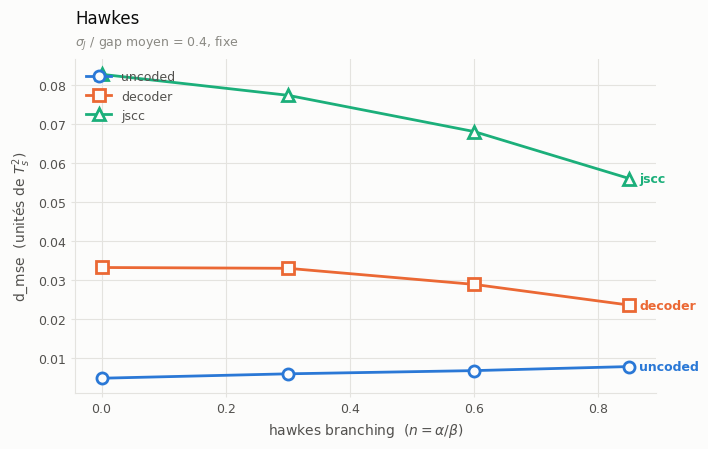

In [13]:
def fig_distortion(rows, metric="d_mse", title="Hawkes"):
    fig, ax = plt.subplots(figsize=(7.2, 4.6), facecolor=SURFACE)
    for mode in MODES:
        pts = sorted([r for r in rows if r["mode"] == mode],
                     key=lambda r: r["hawkes_branching"])
        if not pts:
            continue
        colour, marker = MODE_STYLE[mode]
        xs = [r["hawkes_branching"] for r in pts]
        ys = [r[metric] for r in pts]
        ax.plot(xs, ys, color=colour, lw=2.0, marker=marker, ms=8, mew=2.0,
                mfc=SURFACE, mec=colour, zorder=5, label=mode)
        ax.annotate(mode, (xs[-1], ys[-1]), textcoords="offset points",
                    xytext=(7, 0), color=colour, fontsize=9, fontweight="bold",
                    va="center")
    unit = "$T_s^2$"
    style(ax, "hawkes branching  ($n = \\alpha/\\beta$)", f"{metric}  (unités de {unit})",
          title, f"$\\sigma_J$ / gap moyen = {SIGMA_RATIO:g}, fixe")
    legend(ax)
    fig.tight_layout()
    return fig


fig_distortion(HAWKES_ROWS)
plt.show()

## Le mapping des écarts (éq. 12) — qu'apprend l'encodeur ?

Pour chaque `branching`, on trace `g_i` (l'écart source) contre `g_i^{(X)}` (l'écart après
encodage) : les temps de bin sélectionnés par l'encodeur, dans l'ordre. Comme `N_X = N_S` est
garanti par construction et qu'un raster est ordonné par indice de bin, le `i`-ième écart du code
correspond au `i`-ième écart de la source pour chaque bloc (même longueur des deux côtés). Si
l'encodeur avait convergé vers l'identité, tous les points seraient sur la diagonale. On regarde
aussi le facteur `g_i^{(X)}/g_i` en fonction de la taille de l'écart source, pour voir si les
petits écarts (intra-rafale) et les grands écarts (silences) sont traités différemment.

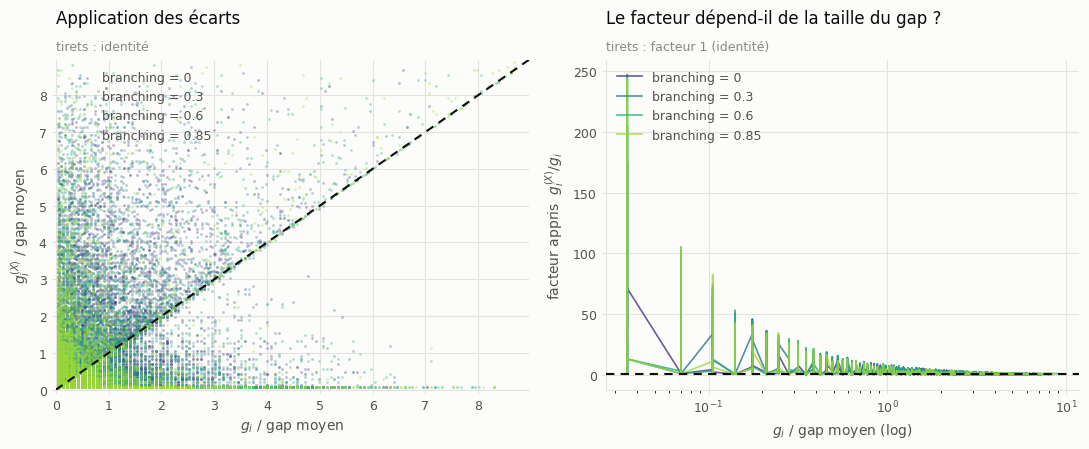

In [14]:
def fig_gap_mapping(models, branchings, n_blocks=GAPMAP_N_BLOCKS, seed=GAPMAP_SEED):
    fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.6), facecolor=SURFACE)
    colours = plt.get_cmap("viridis")(np.linspace(0.15, 0.85, len(branchings)))
    lim = 0.0
    for colour, b in zip(colours, branchings):
        model, cfg, _ = models[(b, "jscc")]
        rng = np.random.default_rng(seed)
        with torch.no_grad():
            r_source, _ = sample_source(cfg, n_blocks, rng)
            r_code = model.encoder(r_source)
        times_s = raster_to_times(r_source, cfg)
        times_x = raster_to_times(r_code, cfg)
        # N_X = N_S garanti par construction : même longueur des deux côtés,
        # bloc par bloc, donc la concaténation aligne bien gap i <-> gap i.
        gs = np.concatenate([np.diff(t, prepend=0.0) for t in times_s]) / cfg.mean_gap
        gx = np.concatenate([np.diff(t, prepend=0.0) for t in times_x]) / cfg.mean_gap
        lim = max(lim, gs.max(initial=0.0), gx.max(initial=0.0))
        axes[0].scatter(gs, gx, s=4, color=colour, alpha=0.35, lw=0,
                        label=f"branching = {b:g}")
        mult = gx / np.clip(gs, 1e-6, None)
        order = np.argsort(gs)
        axes[1].plot(gs[order], mult[order], color=colour, lw=1.2, alpha=0.8,
                     label=f"branching = {b:g}")

    axes[0].plot([0, lim], [0, lim], color=INK, lw=1.5, ls=(0, (4, 3)), zorder=4)
    axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
    style(axes[0], "$g_i$ / gap moyen", "$g_i^{(X)}$ / gap moyen",
          "Application des écarts", "tirets : identité")
    legend(axes[0])

    axes[1].axhline(1.0, color=INK, lw=1.5, ls=(0, (4, 3)), zorder=4)
    axes[1].set_xscale("log")
    style(axes[1], "$g_i$ / gap moyen (log)", "facteur appris  $g_i^{(X)} / g_i$",
          "Le facteur dépend-il de la taille du gap ?", "tirets : facteur 1 (identité)")
    legend(axes[1])
    fig.tight_layout()
    return fig


fig_gap_mapping(HAWKES_MODELS, [0.0, 0.3, 0.6, 0.85])
plt.show()

## Une réalisation à travers la chaîne

Chaque étage (source, code, sortie canal, reconstruction) est un raster ; on affiche les temps de
bin correspondant aux positions à `1`. Répété sur plusieurs blocs pour voir la variabilité de
`N_S` (nombre d'événements réels) d'un bloc à l'autre, puisque N n'est plus fixé par la source.

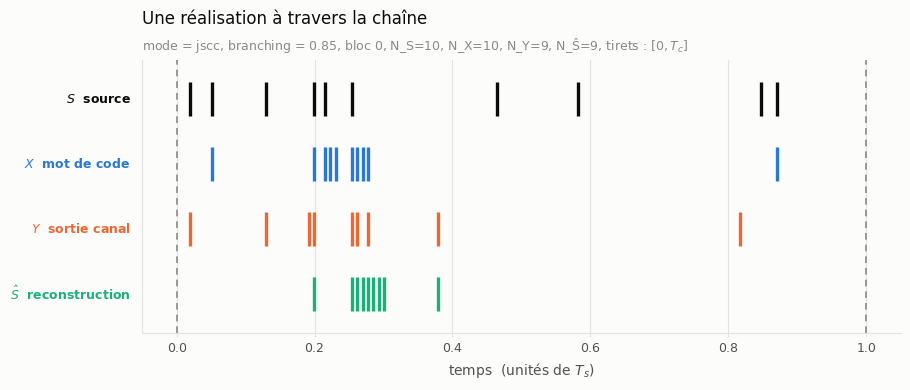

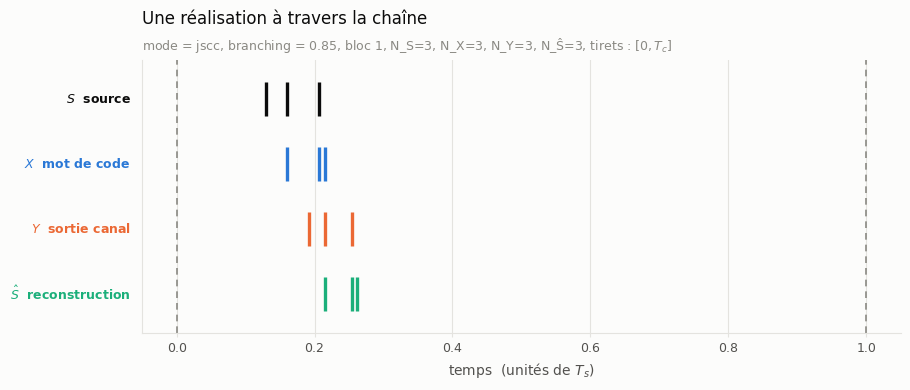

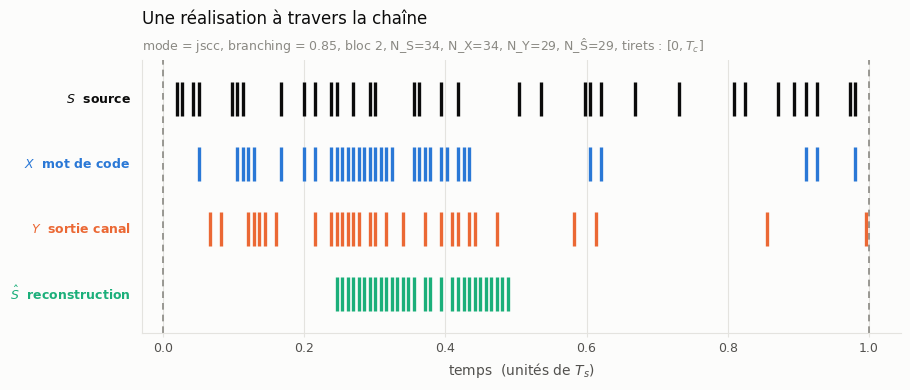

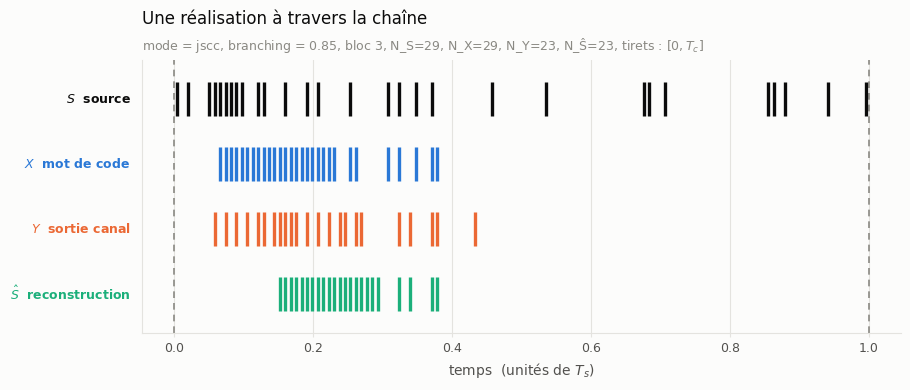

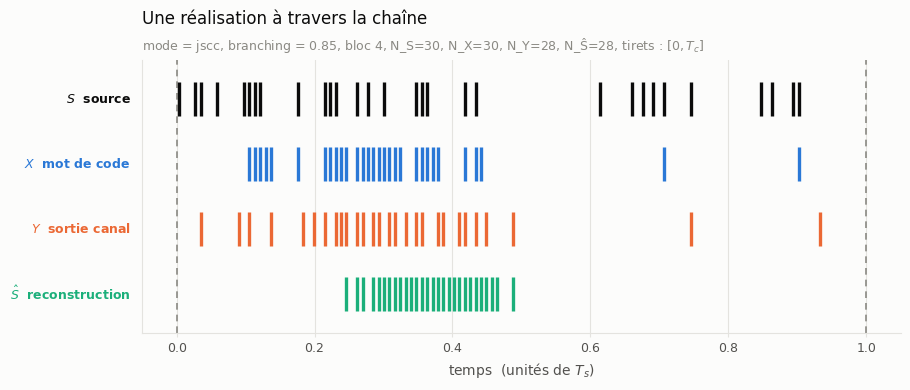

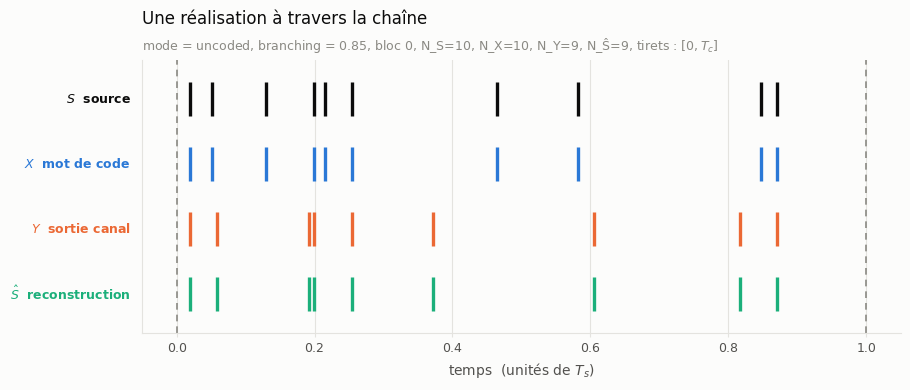

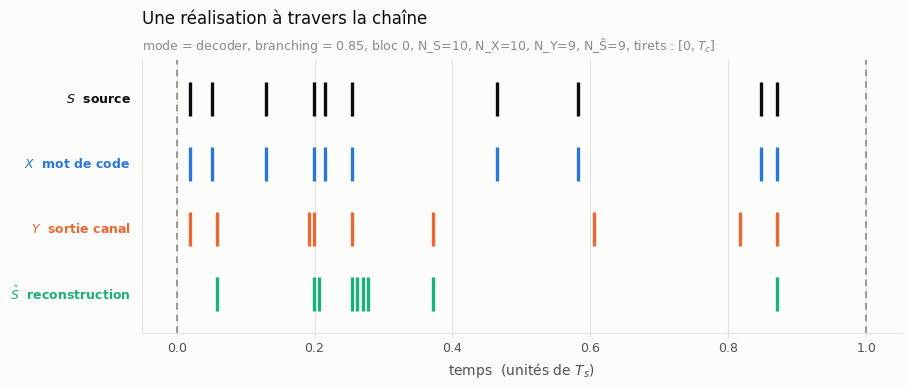

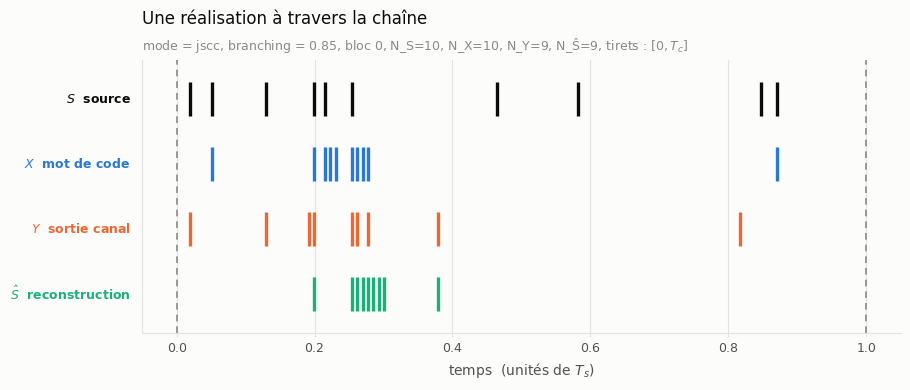

In [15]:
def fig_realisation(models, b, mode="jscc", block=0, seed=REALISATION_SEED):
    model, cfg, _ = models[(b, mode)]
    rng = np.random.default_rng(seed)
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    with torch.no_grad():
        r_source, _ = sample_source(cfg, block + 1, rng)
        out = model(r_source, gen=gen)
    S = raster_to_times(r_source, cfg)[block]
    X = raster_to_times(out["r_code"], cfg)[block]
    Y = raster_to_times(out["r_channel"], cfg)[block]
    H = raster_to_times(out["r_hat"], cfg)[block]

    rows = [("$S$  source", S, INK), ("$X$  mot de code", X, C_UNCODED),
            ("$Y$  sortie canal", Y, C_DECODER), ("$\\hat{S}$  reconstruction", H, C_JSCC)]
    fig, ax = plt.subplots(figsize=(9.2, 4.0), facecolor=SURFACE)
    for k, (name, vals, colour) in enumerate(rows):
        y0 = len(rows) - 1 - k
        ax.eventplot([vals], colors=colour, lineoffsets=y0, linelengths=0.52,
                     linewidths=2.4, zorder=6)
        ax.text(-0.015, y0, name, transform=ax.get_yaxis_transform(), color=colour,
                fontsize=9, fontweight="bold", ha="right", va="center")
    for xv in (0.0, cfg.Tc):
        ax.axvline(xv, color=MUTED, lw=1.2, ls=(0, (4, 3)), zorder=2)
    sub = (f"mode = {mode}, branching = {b:g}, bloc {block}, "
           f"N_S={len(S)}, N_X={len(X)}, N_Y={len(Y)}, N_Ŝ={len(H)}, "
           f"tirets : $[0, T_c]$")
    ax.set_ylim(-0.6, 3.6); ax.set_yticks([])
    style(ax, "temps  (unités de $T_s$)", "", "Une réalisation à travers la chaîne", sub)
    fig.tight_layout()
    return fig


for blk in REALISATION_BLOCKS:
    fig_realisation(HAWKES_MODELS, 0.85, mode="jscc", block=blk)
    plt.show()

for m in MODES:
    fig_realisation(HAWKES_MODELS, 0.85, mode=m, block=REALISATION_BLOCKS[0])
    plt.show()

## Limites et choix à assumer

### Difficulté d'optimisation résiduelle (à discuter avec l'encadrant)

Même après avoir corrigé les deux ruptures de gradient (canal, seuil LIF) et être passé à la
vraie distorsion du PDF, `decoder` et `jscc` restent nettement pires que `uncoded` sur le budget
testé -- `decoder` seul devrait pourtant pouvoir apprendre l'identité et au moins égaler `uncoded`.
Causes probables, cumulatives :

1. **Déroulement récurrent long** (`T_bins=128` pas) à travers un réseau à surrogate gradient :
   les gradients à travers de longues séquences récurrentes sont connus pour s'atténuer/se
   bruiter (comme pour les RNN classiques), et l'erreur d'approximation du surrogate arctan
   s'accumule sur les 128 pas.
2. **Deux mécanismes top-N empilés** (encodeur, décodeur), chacun un straight-through
   (sélection dure en avant, gradient lissé en arrière) -- une approximation par mécanisme, et
   elles se combinent en série à travers le canal.
3. **La distorsion fidèle au PDF ajoute une troisième couche d'approximation** : l'estimation
   molle de `T̂_i` (noyau gaussien sur le rang cumulé, `temp_rank`) a son propre compromis
   biais/variance -- mal réglée, elle peut donner un gradient qui pointe dans une direction
   légèrement fausse (cf. le piège p=0.5 déjà trouvé et corrigé, qui montre que ce genre d'erreur
   silencieuse est facile à introduire ici).
4. **Le taux d'apprentissage d'origine (3e-3, hérité de la version continue du notebook) fait
   diverger cette loss** : bonne au début (~step 150), elle explose ensuite vers un plateau 5 à
   15x pire. Un taux 10x plus bas (3e-4) stabilise sans totalement résoudre le problème.
5. Le PDF anticipe explicitement ce genre de difficulté ("Optimization issue: be careful about
   possible optimization issues") -- sa section "Step 3" (modèle minimal à deux événements)
   suggère précisément de réduire à l'échelle la plus petite possible pour isoler le mécanisme
   avant de repasser à l'échelle complète, une piste naturelle pour la suite.

### Autres limites assumées

- **Collisions de bins non négligeables**, surtout en régime rafale (`frac_source_collision` et
  `frac_channel_collision`, suivies dans le tableau) : la source Hawkes a une proportion notable
  d'écarts plus petits que `bin_width`, y compris à `T_bins` bien plus grand que 128 (mesuré
  jusqu'à `T_bins=1024`, cf. markdown d'intro). Conséquence assumée du passage à un vrai raster
  de spikes, pas un bug à corriger dans ce notebook.
- **Un seul seed par point** du sweep : les écarts entre `decoder` et `jscc` sont à lire avec
  cette réserve — pas de barre d'erreur ici.
- **`sigma_J` fixe** pour tout le sweep en branching : un sweep croisé (branching x sigma) donnerait
  une vue plus complète, mais multiplie le coût par la taille de la seconde grille.
- Le SNN reste volontairement **à une seule couche cachée feed-forward** — un choix de simplicité,
  pas une limite de capacité démontrée.

## Comparaison rapide entre types de source (Poisson, renouvellement Gamma, Hawkes)

Le PDF propose une progression : **Step 1** (Poisson, la source la plus "aléatoire", où l'encodeur
pourrait raisonnablement converger vers l'identité), **Step 2** (renouvellement, eq. 10 :
`W_i ~ Gamma(k, mean_gap/k)`, plus prévisible quand `k` grandit), et l'extension Hawkes de ce
notebook (mémoire multi-événements). Même pipeline exact (SNN, canal, top-N, distorsion fidèle au
PDF) que plus haut, juste la fonction source qui change — pour un budget d'entraînement réduit
(`800` pas au lieu de `3000`, pour rester rapide) : les chiffres sont donc indicatifs, pas le
résultat final du sweep principal.

In [16]:
def sample_poisson(cfg: Config, batch: int, rng: np.random.Generator):
    """Processus de Poisson homogène = renouvellement exponentiel i.i.d.
    (PDF, Step 1). Même logique fenêtre Ts fixe / N aléatoire que sample_source."""
    r = torch.zeros(batch, cfg.T_bins, dtype=torch.float32, device=DEVICE)
    n_raw = np.zeros(batch, dtype=np.int64)
    for b in range(batch):
        t, times = 0.0, []
        while len(times) < cfg.max_events_cap:
            t += rng.exponential(cfg.mean_gap)
            if t >= cfg.Ts:
                break
            times.append(t)
        n_raw[b] = len(times)
        if times:
            idx = np.minimum((np.array(times) / cfg.bin_width).astype(np.int64), cfg.T_bins - 1)
            r[b, idx] = 1.0
    return r, n_raw


def sample_gamma_renewal(cfg: Config, batch: int, rng: np.random.Generator, k: float):
    """Renouvellement Gamma, W_i ~ Gamma(k, mean_gap/k) i.i.d. (PDF eq. 10).
    k=1 -> exponentiel (Poisson) ; k grand -> timing de plus en plus régulier."""
    r = torch.zeros(batch, cfg.T_bins, dtype=torch.float32, device=DEVICE)
    n_raw = np.zeros(batch, dtype=np.int64)
    for b in range(batch):
        t, times = 0.0, []
        while len(times) < cfg.max_events_cap:
            t += rng.gamma(shape=k, scale=cfg.mean_gap / k)
            if t >= cfg.Ts:
                break
            times.append(t)
        n_raw[b] = len(times)
        if times:
            idx = np.minimum((np.array(times) / cfg.bin_width).astype(np.int64), cfg.T_bins - 1)
            r[b, idx] = 1.0
    return r, n_raw


def quick_train_eval(sampler, mode: str, cfg: Config, steps: int = 800, seed: int = 2):
    """Comme train_system/measure, mais paramétré par la fonction source
    (sampler(cfg, batch, rng) -> (r, n_raw)) -- même pipeline (SNN, canal,
    top-N, distorsion fidèle au PDF) que le sweep Hawkes, pour comparer
    rapidement plusieurs types de source."""
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    gen = torch.Generator(device=DEVICE).manual_seed(seed + 1)
    model = System(cfg, mode).to(DEVICE)
    if model.n_params > 0:
        opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr)
        sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=cfg.lr,
                                                    total_steps=steps, pct_start=0.1)
        for step in range(steps):
            r_source, _ = sampler(cfg, cfg.batch, rng)
            out = model(r_source, gen=gen)
            loss, _, _ = pdf_distortion(r_source, out, cfg)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            sched.step()
    with torch.no_grad():
        r_eval, n_raw = sampler(cfg, cfg.eval_batch, np.random.default_rng(9999))
        gen_eval = torch.Generator(device=DEVICE).manual_seed(10000)
        out = model(r_eval, gen=gen_eval)
        n_s = r_eval.sum(dim=1)
        n_hat = out["r_hat"].sum(dim=1)
        N_max = max(int(n_s.max().item()), 1)
        t_true, mask_true = exact_rank_times(r_eval, cfg, N_max)
        t_hat, _ = exact_rank_times(out["r_hat"], cfg, N_max)
        n_match = torch.minimum(n_s, n_hat)
        idx = torch.arange(N_max, device=DEVICE).unsqueeze(0)
        mask_match = (idx < n_match.unsqueeze(1)) & mask_true
        block_d = ((t_true - t_hat) ** 2 * mask_match.float()).sum(dim=1) / n_match.clamp(min=1).float()
        coll = float((torch.as_tensor(n_raw) != n_s).float().mean())
    return model, {"d_mse": float(block_d.mean()), "mean_n_s": float(n_s.mean()),
                   "frac_source_collision": coll, "mode": mode}

In [17]:
QUICK_STEPS = 800
SOURCE_SAMPLERS = {
    "poisson": lambda cfg, b, rng: sample_poisson(cfg, b, rng),
    "gamma_k4": lambda cfg, b, rng: sample_gamma_renewal(cfg, b, rng, k=4.0),
    "hawkes": lambda cfg, b, rng: sample_source(cfg, b, rng),  # CFG.hawkes_branching par défaut (0.5)
}

QUICK_ROWS, QUICK_MODELS = [], {}
for name, sampler in SOURCE_SAMPLERS.items():
    for mode in MODES:
        model, m = quick_train_eval(sampler, mode, CFG, steps=QUICK_STEPS)
        m["source"] = name
        QUICK_ROWS.append(m)
        QUICK_MODELS[(name, mode)] = model
        print(f"{name:10s} {mode:8s}  d_mse={m['d_mse']:.4f}  mean_n_s={m['mean_n_s']:.1f}"
              f"  frac_collision={m['frac_source_collision']:.3f}", flush=True)

show_table(QUICK_ROWS, cols=["source", "mode", "d_mse", "mean_n_s", "frac_source_collision"],
           title=f"Comparaison rapide de sources (steps={QUICK_STEPS}, T_bins={CFG.T_bins})")

poisson    uncoded   d_mse=0.0042  mean_n_s=8.7  frac_collision=0.265


poisson    decoder   d_mse=0.0240  mean_n_s=8.7  frac_collision=0.265


poisson    jscc      d_mse=0.0712  mean_n_s=8.7  frac_collision=0.265


gamma_k4   uncoded   d_mse=0.0019  mean_n_s=8.6  frac_collision=0.001


gamma_k4   decoder   d_mse=0.0166  mean_n_s=8.6  frac_collision=0.001


gamma_k4   jscc      d_mse=0.0630  mean_n_s=8.6  frac_collision=0.001


hawkes     uncoded   d_mse=0.0054  mean_n_s=9.4  frac_collision=0.384


hawkes     decoder   d_mse=0.0225  mean_n_s=9.4  frac_collision=0.384


hawkes     jscc      d_mse=0.0619  mean_n_s=9.4  frac_collision=0.384


Comparaison rapide de sources (steps=800, T_bins=128)
     source |        mode |       d_mse |    mean_n_s | frac_source_collision
------------+-------------+-------------+-------------+----------------------
    poisson |     uncoded |      0.0042 |      8.7069 |                0.2650
    poisson |     decoder |      0.0240 |      8.7069 |                0.2650
    poisson |        jscc |      0.0712 |      8.7069 |                0.2650
   gamma_k4 |     uncoded |      0.0019 |      8.6344 |            6.2500e-04
   gamma_k4 |     decoder |      0.0166 |      8.6344 |            6.2500e-04
   gamma_k4 |        jscc |      0.0630 |      8.6344 |            6.2500e-04
     hawkes |     uncoded |      0.0054 |      9.4239 |                0.3841
     hawkes |     decoder |      0.0225 |      9.4239 |                0.3841
     hawkes |        jscc |      0.0619 |      9.4239 |                0.3841


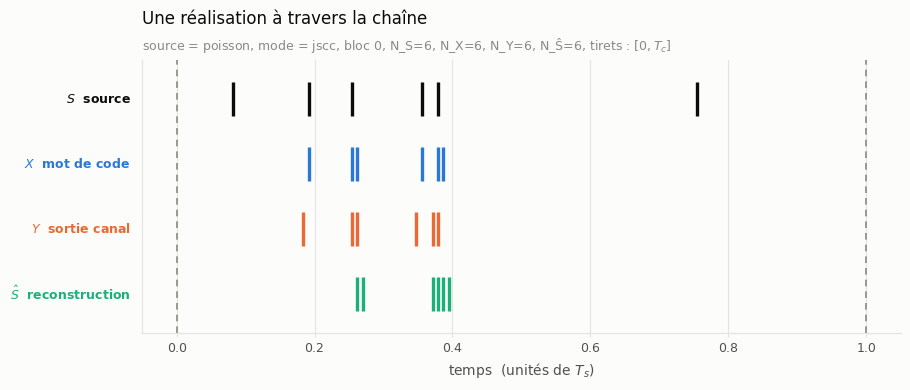

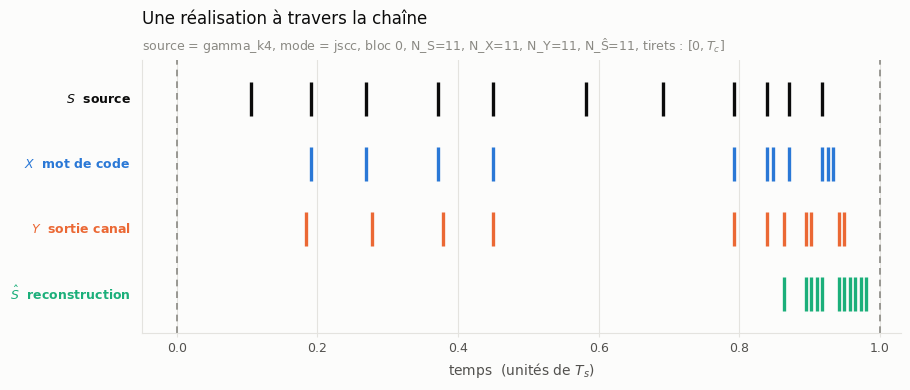

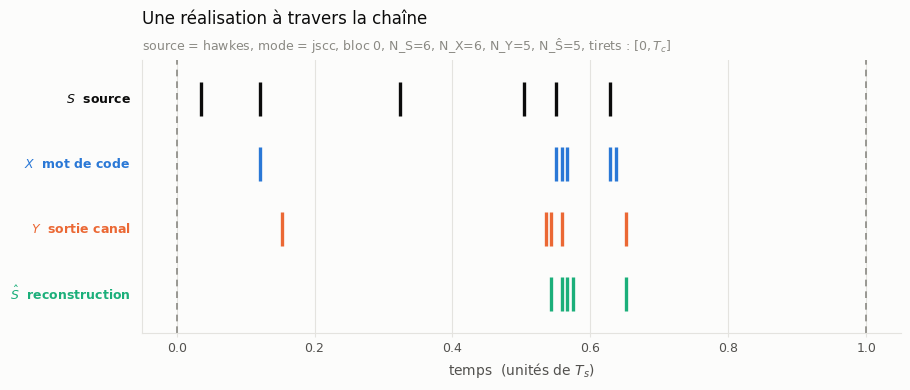

In [18]:
def fig_realisation_generic(sampler, model, cfg: Config, title_prefix: str,
                             block: int = 0, seed: int = REALISATION_SEED):
    """Comme fig_realisation, mais paramétré par une fonction source
    quelconque plutôt que par (HAWKES_MODELS, branching) -- pour comparer la
    chaîne complète S -> X -> Y -> Ŝ entre types de source."""
    rng = np.random.default_rng(seed)
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    with torch.no_grad():
        r_source, _ = sampler(cfg, block + 1, rng)
        out = model(r_source, gen=gen)
    S = raster_to_times(r_source, cfg)[block]
    X = raster_to_times(out["r_code"], cfg)[block]
    Y = raster_to_times(out["r_channel"], cfg)[block]
    H = raster_to_times(out["r_hat"], cfg)[block]

    rows = [("$S$  source", S, INK), ("$X$  mot de code", X, C_UNCODED),
            ("$Y$  sortie canal", Y, C_DECODER), ("$\\hat{S}$  reconstruction", H, C_JSCC)]
    fig, ax = plt.subplots(figsize=(9.2, 4.0), facecolor=SURFACE)
    for k, (name, vals, colour) in enumerate(rows):
        y0 = len(rows) - 1 - k
        ax.eventplot([vals], colors=colour, lineoffsets=y0, linelengths=0.52,
                     linewidths=2.4, zorder=6)
        ax.text(-0.015, y0, name, transform=ax.get_yaxis_transform(), color=colour,
                fontsize=9, fontweight="bold", ha="right", va="center")
    for xv in (0.0, cfg.Tc):
        ax.axvline(xv, color=MUTED, lw=1.2, ls=(0, (4, 3)), zorder=2)
    sub = (f"source = {title_prefix}, mode = jscc, bloc {block}, "
           f"N_S={len(S)}, N_X={len(X)}, N_Y={len(Y)}, N_Ŝ={len(H)}, tirets : $[0, T_c]$")
    ax.set_ylim(-0.6, 3.6); ax.set_yticks([])
    style(ax, "temps  (unités de $T_s$)", "", "Une réalisation à travers la chaîne", sub)
    fig.tight_layout()
    return fig


for name, sampler in SOURCE_SAMPLERS.items():
    fig_realisation_generic(sampler, QUICK_MODELS[(name, "jscc")], CFG, title_prefix=name)
    plt.show()

## Pourquoi l'encodeur se regroupe-t-il dans une bande étroite plutôt que de suivre chaque événement ?

En regardant directement les figures "chaîne complète" ci-dessus : la source Poisson s'étale de
`0.08` à `0.75` (6 événements), mais `X` (mot de code) compresse tout dans `0.18`-`0.4` --
l'événement isolé à `0.75` n'a **aucun** équivalent dans le code, l'encodeur ne fait que rajouter
de la densité dans sa bande habituelle. Même chose pour Hawkes : source `0.05`-`0.68`, code
regroupé en deux paquets serrés vers `0.5`-`0.68`. Vérifié numériquement (histogramme des positions
choisies sur 2000 blocs) : l'encodeur privilégie systématiquement les mêmes zones de bins d'un
bloc à l'autre, peu importe le contenu réel de ce bloc.

**Explication mécaniste.** L'entrée est très éparse (la plupart des `T_bins=128` pas reçoivent un
`0`, donc un courant nul). Sur une longue plage de zéros, le potentiel de membrane `u` évolue par
pure décroissance déterministe (`u_t = beta * u_{t-1}`), **indépendamment du contenu du bloc** --
seule la position temporelle `t` compte, pas ce qui s'est réellement passé avant. Le score `raw(t)`
sur les 128 pas ressemble donc surtout à une trajectoire **fixe**, apprise une fois pour toutes
par les poids du réseau, à peine perturbée par les quelques vrais spikes du bloc. Le top-N
sélectionne alors les positions où cette trajectoire fixe culmine -- pas les positions réelles des
événements. C'est un raccourci appris typique quand le signal de gradient par-événement est trop
faible pour être exploité (cf. "Difficulté d'optimisation résiduelle" plus bas) : le réseau
retombe sur un **biais positionnel** plutôt que de suivre l'entrée spécifique à chaque bloc.

## Et si on remplaçait le top-N structurel par une pénalité ?

Question testée directement : au lieu de forcer `N_X = N_S` par construction (top-N par rang),
laisser chaque bin décider seul (`spike(raw)`, seuil appris via le biais du réseau, comme un
neurone spiking "classique") et ajouter une pénalité `lambda * (N_X - N_S)²` dans la loss pour
*encourager* le bon compte, sans le garantir. Repris sur Poisson et le renouvellement Gamma (k=4),
budget réduit (`1500` pas au lieu de `3000`) pour rester rapide.

`lambda` balayé rapidement (5 / 20 / 50) : au-delà de 20, plus de gain -- valeur retenue ici.

poisson     mean_n_s=8.66  mean_n_code=21.27  mean_n_hat=33.57  frac_exact=0.028  d_mse=0.2361
gamma_k4    mean_n_s=8.67  mean_n_code=19.90  mean_n_hat=28.66  frac_exact=0.003  d_mse=0.2477
Contrainte par pénalité (lambda=20, steps=1500) -- comparer à n_code_matches_n_s=1.0000 exact avec le top-N structurel
     source |    mean_n_s | mean_n_code |  mean_n_hat | mean_abs_diff_code | frac_exact_code |       d_mse
------------+-------------+-------------+-------------+--------------------+-----------------+------------
    poisson |      8.6605 |     21.2715 |     33.5690 |            13.3980 |          0.0280 |      0.2361
   gamma_k4 |      8.6695 |     19.8985 |     28.6630 |            11.2390 |          0.0030 |      0.2477


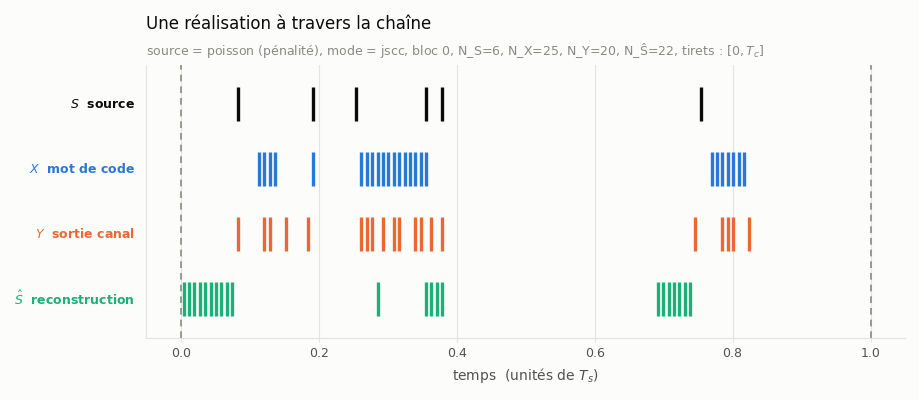

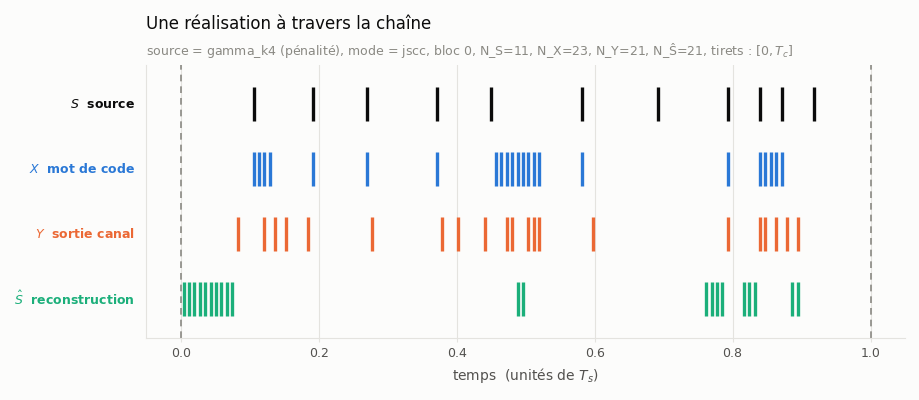

In [999]:
def fig_realisation_generic(sampler, model, cfg: Config, title_prefix: str,
                             block: int = 0, seed: int = REALISATION_SEED):
    """Comme fig_realisation, mais paramétré par une fonction source
    quelconque plutôt que par (HAWKES_MODELS, branching)."""
    rng = np.random.default_rng(seed)
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    with torch.no_grad():
        r_source, _ = sampler(cfg, block + 1, rng)
        out = model(r_source, gen=gen)
    S = raster_to_times(r_source, cfg)[block]
    X = raster_to_times(out["r_code"], cfg)[block]
    Y = raster_to_times(out["r_channel"], cfg)[block]
    H = raster_to_times(out["r_hat"], cfg)[block]

    rows = [("$S$  source", S, INK), ("$X$  mot de code", X, C_UNCODED),
            ("$Y$  sortie canal", Y, C_DECODER), ("$\\hat{S}$  reconstruction", H, C_JSCC)]
    fig, ax = plt.subplots(figsize=(9.2, 4.0), facecolor=SURFACE)
    for k, (name, vals, colour) in enumerate(rows):
        y0 = len(rows) - 1 - k
        ax.eventplot([vals], colors=colour, lineoffsets=y0, linelengths=0.52,
                     linewidths=2.4, zorder=6)
        ax.text(-0.015, y0, name, transform=ax.get_yaxis_transform(), color=colour,
                fontsize=9, fontweight="bold", ha="right", va="center")
    for xv in (0.0, cfg.Tc):
        ax.axvline(xv, color=MUTED, lw=1.2, ls=(0, (4, 3)), zorder=2)
    sub = (f"source = {title_prefix}, mode = jscc, bloc {block}, "
           f"N_S={len(S)}, N_X={len(X)}, N_Y={len(Y)}, N_Ŝ={len(H)}, tirets : $[0, T_c]$")
    ax.set_ylim(-0.6, 3.6); ax.set_yticks([])
    style(ax, "temps  (unités de $T_s$)", "", "Une réalisation à travers la chaîne", sub)
    fig.tight_layout()
    return fig


def show_table(rows, cols=None, title=""):
    cols = cols or list(rows[0].keys())
    w = {c: max(len(c), 11) for c in cols}
    if title:
        print(title)
    print(" | ".join(c.rjust(w[c]) for c in cols))
    print("-+-".join("-" * w[c] for c in cols))
    for r in rows:
        cells_ = []
        for c in cols:
            v = r.get(c, "")
            if isinstance(v, float):
                v = f"{v:.4e}" if (v != 0 and abs(v) < 1e-3) else f"{v:.4f}"
            cells_.append(str(v).rjust(w[c]))
        print(" | ".join(cells_))


class EncoderPenalty(nn.Module):
    """Comme Encoder, mais SANS top-N : chaque bin décide seul (Heaviside sur
    son propre score, seuil appris via le biais de `head`). Rien ne garantit
    N_X = N_S -- c'est justement ce qu'on teste."""

    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = SimpleSNN(cfg, n_in=1)

    def forward(self, r_source: torch.Tensor):
        raw = self.net(r_source.unsqueeze(-1))
        r_code = spike(raw, self.cfg.spike_alpha)
        return r_code, raw


class DecoderPenalty(nn.Module):
    """Idem pour le décodeur. `tau=0` (le seuil de décision réel de `spike`)
    remplace le seuil top-N dans `rank_times`/`pdf_distortion`, qui n'ont pas
    besoin d'être modifiés -- ils ne font aucune hypothèse sur *comment* tau
    a été obtenu, seulement qu'il définit "ce bin est sélectionné"."""

    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = SimpleSNN(cfg, n_in=1)

    def forward(self, r_channel: torch.Tensor):
        raw = self.net(r_channel.unsqueeze(-1))
        r_hat = spike(raw, self.cfg.spike_alpha)
        tau = torch.zeros(r_channel.shape[0], device=r_channel.device)
        return r_hat, raw, tau


class SystemPenalty(nn.Module):
    """Toujours mode jscc (encodeur+décodeur) -- c'est le seul cas où la
    contrainte N_X=N_S a un sens à comparer."""

    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.encoder = EncoderPenalty(cfg)
        self.decoder = DecoderPenalty(cfg)

    def forward(self, r_source, sigma=None, gen=None):
        sigma = self.cfg.sigma_J if sigma is None else sigma
        r_code, _ = self.encoder(r_source)
        r_channel = channel(r_code, sigma, self.cfg, gen)
        r_hat, raw_dec, tau_dec = self.decoder(r_channel)
        return {"r_hat": r_hat, "r_code": r_code, "r_channel": r_channel,
                "raw_dec": raw_dec, "tau_dec": tau_dec}

    @property
    def n_params(self):
        return sum(p.numel() for p in self.parameters())


def penalty_loss(r_source, out, cfg: Config, lambda_count: float = 20.0, temp_rank: float = 0.3):
    """distorsion PDF + pénalité quadratique sur l'écart de compte, aux DEUX
    étages (encodeur: N_X vs N_S: décodeur: N_Ŝ vs N_channel). `lambda_count`
    choisi après un petit sweep (5/20/50) : au-delà de 20, plus de gain."""
    d, _, _ = pdf_distortion(r_source, out, cfg, temp_rank)
    n_s = r_source.sum(dim=1)
    n_code = out["r_code"].sum(dim=1)
    n_channel = out["r_channel"].sum(dim=1)
    n_hat = out["r_hat"].sum(dim=1)
    count_pen = ((n_code - n_s) ** 2 + (n_hat - n_channel) ** 2).mean()
    return d + lambda_count * cfg.mean_gap ** 2 * count_pen


PENALTY_STEPS = 1500
PENALTY_SOURCES = {
    "poisson": lambda cfg, b, rng: sample_poisson(cfg, b, rng),
    "gamma_k4": lambda cfg, b, rng: sample_gamma_renewal(cfg, b, rng, k=4.0),
}

PENALTY_ROWS, PENALTY_MODELS = [], {}
for name, sampler in PENALTY_SOURCES.items():
    torch.manual_seed(2)
    rng = np.random.default_rng(2)
    gen = torch.Generator(device=DEVICE).manual_seed(3)
    model = SystemPenalty(CFG)
    opt = torch.optim.AdamW(model.parameters(), lr=CFG.lr)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=CFG.lr,
                                                total_steps=PENALTY_STEPS, pct_start=0.1)
    for step in range(PENALTY_STEPS):
        r_source, _ = sampler(CFG, CFG.batch, rng)
        out = model(r_source, gen=gen)
        loss = penalty_loss(r_source, out, CFG)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        sched.step()

    with torch.no_grad():
        r_eval, _ = sampler(CFG, 2000, np.random.default_rng(999))
        gen_eval = torch.Generator(device=DEVICE).manual_seed(1000)
        out = model(r_eval, gen=gen_eval)
        n_s = r_eval.sum(dim=1)
        n_code = out["r_code"].sum(dim=1)
        n_channel = out["r_channel"].sum(dim=1)
        n_hat = out["r_hat"].sum(dim=1)
        N_max = max(int(n_s.max().item()), 1)
        t_true, mask_true = exact_rank_times(r_eval, CFG, N_max)
        t_hat, _ = exact_rank_times(out["r_hat"], CFG, N_max)
        n_match = torch.minimum(n_s, n_hat)
        idx = torch.arange(N_max).unsqueeze(0)
        mask_match = (idx < n_match.unsqueeze(1)) & mask_true
        d_pdf = (((t_true - t_hat) ** 2 * mask_match.float()).sum(dim=1)
                 / n_match.clamp(min=1).float()).mean()

    row = {"source": name, "mean_n_s": float(n_s.mean()), "mean_n_code": float(n_code.mean()),
           "mean_n_hat": float(n_hat.mean()), "mean_abs_diff_code": float((n_code - n_s).abs().mean()),
           "frac_exact_code": float((n_code == n_s).float().mean()), "d_mse": float(d_pdf)}
    PENALTY_ROWS.append(row)
    PENALTY_MODELS[name] = model
    print(f"{name:10s}  mean_n_s={row['mean_n_s']:.2f}  mean_n_code={row['mean_n_code']:.2f}"
          f"  mean_n_hat={row['mean_n_hat']:.2f}  frac_exact={row['frac_exact_code']:.3f}"
          f"  d_mse={row['d_mse']:.4f}")

show_table(PENALTY_ROWS,
           cols=["source", "mean_n_s", "mean_n_code", "mean_n_hat", "mean_abs_diff_code",
                 "frac_exact_code", "d_mse"],
           title=f"Contrainte par pénalité (lambda=20, steps={PENALTY_STEPS}) -- comparer à "
                 f"n_code_matches_n_s=1.0000 exact avec le top-N structurel")

for name, sampler in PENALTY_SOURCES.items():
    fig_realisation_generic(sampler, PENALTY_MODELS[name], CFG, title_prefix=f"{name} (pénalité)")
    plt.show()

## Troisième mécanisme : l'encodeur produit directement des Δt appris (pas un raster)

Après discussion avec l'encadrant : plutôt que de sélectionner des bins (top-N) ou de laisser
chaque bin décider seul (pénalité), l'encodeur peut produire directement une **séquence de `Δt`
appris**, un par événement d'entrée -- le mot de code continu `X = cumsum(Δt)`. `N_X = N_S` devient
alors trivial par construction : on lit le score du réseau *exactement* aux positions où il y a un
vrai spike en entrée, donc on obtient mécaniquement autant de `Δt` que d'événements, sans top-N ni
pénalité.

**Ce qui change concrètement** :
- L'entrée du SNN reste le raster `T_bins` (inchangé, toujours un vrai train de spikes).
- La sortie n'est plus un raster : c'est une séquence continue de temps `X` (comme dans la toute
  première version de ce notebook), obtenue via `Δt_i = softplus(raw_i)` puis `X = cumsum(Δt)`,
  bornée par `clamp(0, T_c)`.
- Le canal redevient un jitter gaussien **continu direct** sur `X` (`Y = X + Z`), sans re-binning
  -- élimine complètement la collision côté source et côté canal.
- Le décodeur doit quand même re-rastériser `Y` pour respecter "l'entrée du SNN = raster" : c'est
  le **seul** point où une collision reste possible (deux temps bruités tombant dans le même bin),
  nettement moins qu'avant. Cette re-rastérisation utilise le même principe straight-through que
  `channel()` (exact en avant, noyau gaussien différentiable en arrière), sinon le gradient ne
  remonterait pas jusqu'à l'encodeur à travers elle -- même bug que celui trouvé pour `channel()`.
- La distorsion devient directement `(T_i - Ŝ_i)²` sur des temps continus -- plus besoin de
  l'estimateur de position pondéré par noyau (`rank_times`), qui était la source du piège p=0.5.

**Ce qui est vérifié en testant, avant d'écrire la cellule finale** :
- `N_X = N_S` exact à 100%, y compris avant tout entraînement (garantie structurelle, comme
  attendu).
- Le gradient atteint bien l'encodeur à travers le canal + la re-rastérisation (vérifié
  explicitement, pas seulement supposé).
- **L'entraînement est nettement plus stable** que la version raster + `rank_times` : la loss
  décroît proprement sans diverger, alors que `lr=3e-3` faisait diverger l'ancienne version.
- **Mais l'écart à `uncoded` persiste** : essayé avec plus de pas (4000 au lieu de 1200) et avec
  un `Δt` reparamétré en `2×mean_gap×sigmoid(raw)` (borné, démarrage plus proche de `mean_gap`) --
  aucun des deux n'a réduit l'écart de façon notable. Le plateau semble réel, pas juste un manque
  de budget ou un mauvais point de départ.

poisson    uncoded   d_mse=0.00091  n_x_ok=nan
poisson    decoder   d_mse=0.02079  n_x_ok=nan
poisson    jscc      d_mse=0.02390  n_x_ok=1.0
gamma_k4   uncoded   d_mse=0.00091  n_x_ok=nan
gamma_k4   decoder   d_mse=0.00682  n_x_ok=nan
gamma_k4   jscc      d_mse=0.00822  n_x_ok=1.0
hawkes     uncoded   d_mse=0.00092  n_x_ok=nan
hawkes     decoder   d_mse=0.03576  n_x_ok=nan
hawkes     jscc      d_mse=0.04681  n_x_ok=1.0
Encodeur à Δt appris (steps=1500) -- comparer aux tableaux précédents
     source |        mode |       d_mse |    mean_n_s | n_x_matches_n_s
------------+-------------+-------------+-------------+----------------
    poisson |     uncoded |  9.0511e-04 |      8.6605 |             nan
    poisson |     decoder |      0.0208 |      8.6605 |             nan
    poisson |        jscc |      0.0239 |      8.6605 |          1.0000
   gamma_k4 |     uncoded |  9.0713e-04 |      8.6695 |             nan
   gamma_k4 |     decoder |      0.0068 |      8.6695 |             nan
   

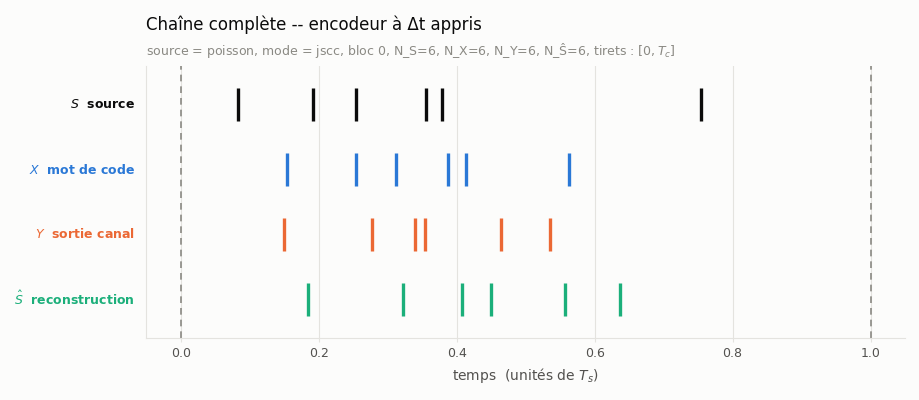

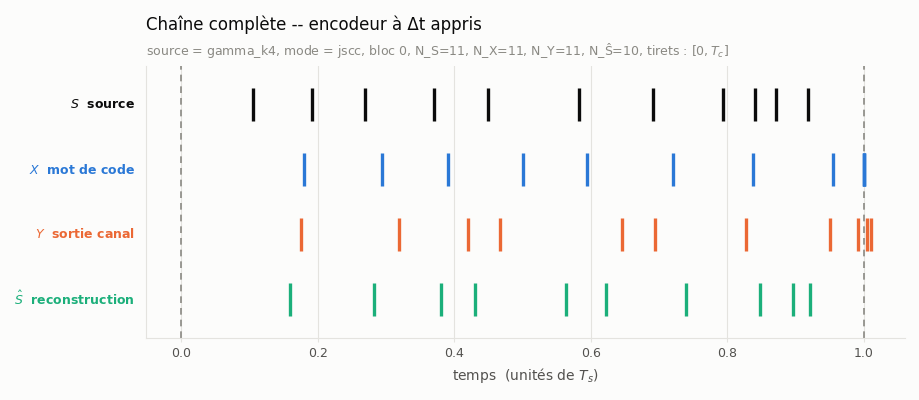

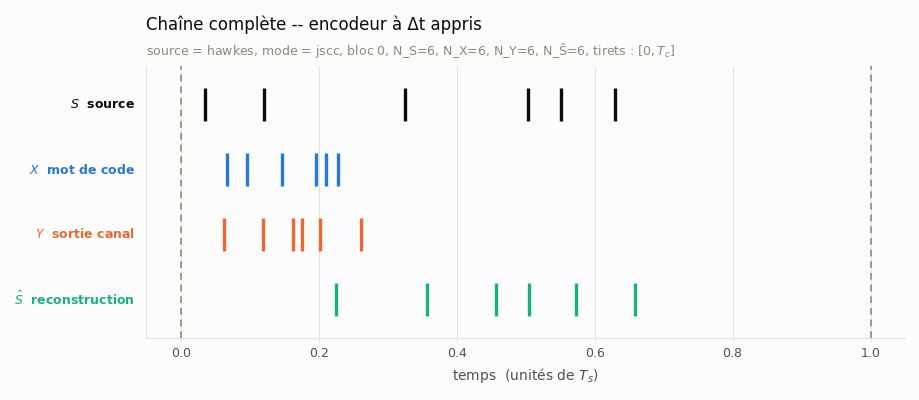

In [1001]:
def fig_realisation_generic(sampler, model, cfg: Config, title_prefix: str,
                             block: int = 0, seed: int = REALISATION_SEED):
    rng = np.random.default_rng(seed)
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    with torch.no_grad():
        r_source, _ = sampler(cfg, block + 1, rng)
        out = model(r_source, gen=gen)
    S = out["t_true"][block][out["mask_true"][block]].numpy()
    X = out["X"][block][out["mask_x"][block]].numpy()
    Y = out["Y"][block][out["mask_x"][block]].numpy()
    H = out["S_hat"][block][out["mask_hat"][block]].numpy()

    rows = [("$S$  source", S, INK), ("$X$  mot de code", X, C_UNCODED),
            ("$Y$  sortie canal", Y, C_DECODER), ("$\\hat{S}$  reconstruction", H, C_JSCC)]
    fig, ax = plt.subplots(figsize=(9.2, 4.0), facecolor=SURFACE)
    for k, (name, vals, colour) in enumerate(rows):
        y0 = len(rows) - 1 - k
        ax.eventplot([vals], colors=colour, lineoffsets=y0, linelengths=0.52,
                     linewidths=2.4, zorder=6)
        ax.text(-0.015, y0, name, transform=ax.get_yaxis_transform(), color=colour,
                fontsize=9, fontweight="bold", ha="right", va="center")
    for xv in (0.0, cfg.Tc):
        ax.axvline(xv, color=MUTED, lw=1.2, ls=(0, (4, 3)), zorder=2)
    sub = (f"source = {title_prefix}, mode = {model.mode}, bloc {block}, "
           f"N_S={len(S)}, N_X={len(X)}, N_Y={len(Y)}, N_Ŝ={len(H)}, tirets : $[0, T_c]$")
    ax.set_ylim(-0.6, 3.6); ax.set_yticks([])
    style(ax, "temps  (unités de $T_s$)", "", "Chaîne complète -- encodeur à Δt appris", sub)
    fig.tight_layout()
    return fig


def show_table(rows, cols=None, title=""):
    cols = cols or list(rows[0].keys())
    w = {c: max(len(c), 11) for c in cols}
    if title:
        print(title)
    print(" | ".join(c.rjust(w[c]) for c in cols))
    print("-+-".join("-" * w[c] for c in cols))
    for r in rows:
        cells_ = []
        for c in cols:
            v = r.get(c, "")
            if isinstance(v, float):
                v = f"{v:.4e}" if (v != 0 and abs(v) < 1e-3) else f"{v:.4f}"
            cells_.append(str(v).rjust(w[c]))
        print(" | ".join(cells_))


def gather_at_spikes(raw: torch.Tensor, r_source: torch.Tensor):
    """(B,T) score, (B,T) raster 0/1 -> (padded (B,N_max), mask (B,N_max)) :
    les scores `raw` AUX positions de spike uniquement, en ordre chronologique
    (le raster est déjà trié par indice de bin), paddés à N_max = max(n_s) du
    batch. Même astuce "bin poubelle" que exact_rank_times, mais on scatter
    les VALEURS de `raw` (différentiables) plutôt que des temps constants."""
    B, T = raw.shape
    n_s = r_source.sum(dim=1)
    N_max = max(int(n_s.max().item()), 1)
    cum = torch.cumsum(r_source, dim=1)
    rank_at_t = (cum - 1).long()
    valid = r_source.bool()
    dustbin = N_max
    idx_safe = torch.where(valid, rank_at_t.clamp(0, N_max - 1), torch.full_like(rank_at_t, dustbin))
    out_ext = torch.zeros(B, N_max + 1, device=raw.device, dtype=raw.dtype)
    mask_ext = torch.zeros(B, N_max + 1, device=raw.device, dtype=torch.bool)
    out_ext.scatter_(1, idx_safe, raw)
    mask_ext.scatter_(1, idx_safe, valid)
    return out_ext[:, :N_max], mask_ext[:, :N_max]


def raster_from_times(Y: torch.Tensor, mask: torch.Tensor, cfg: Config):
    """(B,N_max) temps continus + masque -> (B,T_bins) raster. Straight-through :
    exact en avant (re-binning dur), noyau gaussien différentiable en arrière
    (même principe que channel(), adapté à une entrée paddée par événement
    plutôt qu'un raster complet) -- nécessaire pour que le gradient remonte de
    la loss du décodeur jusqu'à l'encodeur à travers cette re-rastérisation."""
    B, N_max = Y.shape
    T = cfg.T_bins
    centers = (torch.arange(T, device=Y.device, dtype=Y.dtype) + 0.5) * cfg.bin_width
    idx = (Y / cfg.bin_width).floor().long().clamp(0, T - 1)
    dustbin = T
    idx_safe = torch.where(mask, idx, torch.full_like(idx, dustbin))
    r_ext = torch.zeros(B, T + 1, device=Y.device, dtype=Y.dtype)
    r_ext.scatter_(1, idx_safe, torch.ones_like(Y))
    hard = r_ext[:, :T]

    kbw = cfg.bin_width
    diff = centers.view(1, 1, T) - Y.unsqueeze(2)           # (B, N_max, T)
    kernel = torch.softmax(-diff ** 2 / (2 * kbw ** 2), dim=-1)
    kernel = kernel * mask.unsqueeze(2).to(kernel.dtype)
    soft = kernel.sum(dim=1)                                 # (B, T)
    return hard.detach() + soft - soft.detach()


def pad_to(t: torch.Tensor, N_max: int):
    if t.shape[1] < N_max:
        pad = torch.zeros(t.shape[0], N_max - t.shape[1], device=t.device, dtype=t.dtype)
        return torch.cat([t, pad], dim=1)
    return t


class EncoderDelta(nn.Module):
    """Sort une séquence de Δt appris (un par événement d'entrée), pas un
    raster. N_X = N_S garanti par construction : on lit `raw` exactement aux
    positions où il y a un vrai spike en entrée, ni plus ni moins."""

    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = SimpleSNN(cfg, n_in=1)

    def forward(self, r_source: torch.Tensor):
        raw = self.net(r_source.unsqueeze(-1))
        raw_padded, mask = gather_at_spikes(raw, r_source)
        delta = F.softplus(raw_padded) * mask.to(raw.dtype)
        X = torch.cumsum(delta, dim=1).clamp(0.0, self.cfg.Tc)
        return X, mask


class DecoderDelta(nn.Module):
    """Même principe : lit son propre raster d'entrée (obtenu en
    re-rastérisant Y), produit un Δt̂ par spike reçu."""

    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = SimpleSNN(cfg, n_in=1)

    def forward(self, r_in: torch.Tensor):
        raw = self.net(r_in.unsqueeze(-1))
        raw_padded, mask = gather_at_spikes(raw, r_in)
        delta = F.softplus(raw_padded) * mask.to(raw.dtype)
        S_hat = torch.cumsum(delta, dim=1).clamp(0.0, self.cfg.Tc)
        return S_hat, mask


class SystemDelta(nn.Module):
    MODES = ("uncoded", "decoder", "jscc")

    def __init__(self, cfg: Config, mode: str):
        super().__init__()
        assert mode in self.MODES
        self.cfg, self.mode = cfg, mode
        self.encoder = EncoderDelta(cfg) if mode == "jscc" else None
        self.decoder = DecoderDelta(cfg) if mode in ("decoder", "jscc") else None

    def forward(self, r_source, sigma=None, gen=None):
        sigma = self.cfg.sigma_J if sigma is None else sigma
        N_max_s = max(int(r_source.sum(dim=1).max().item()), 1)
        t_true, mask_true = exact_rank_times(r_source, self.cfg, N_max_s)
        if self.encoder is None:
            X, mask_x = t_true, mask_true          # uncoded : X = S (quantifié aux bins)
        else:
            X, mask_x = self.encoder(r_source)
        Z = torch.randn(X.shape, generator=gen, device=X.device) * sigma
        Y = X + Z                                    # canal continu, direct, pas de re-binning
        if self.decoder is None:
            S_hat, mask_hat = Y, mask_x
        else:
            r_in = raster_from_times(Y, mask_x, self.cfg)   # re-rastérisation, seule collision possible
            S_hat, mask_hat = self.decoder(r_in)
        return {"t_true": t_true, "mask_true": mask_true, "X": X, "mask_x": mask_x,
                "Y": Y, "S_hat": S_hat, "mask_hat": mask_hat}

    @property
    def n_params(self):
        return sum(p.numel() for p in self.parameters())


def delta_distortion(out: dict):
    """(T_i - Ŝ_i)² direct -- plus besoin de rank_times : X et Ŝ sont déjà des
    temps continus, pas des rasters à décoder mollement."""
    t_true, mask_true = out["t_true"], out["mask_true"]
    S_hat, mask_hat = out["S_hat"], out["mask_hat"]
    N_max = max(t_true.shape[1], S_hat.shape[1])
    t_true, S_hat = pad_to(t_true, N_max), pad_to(S_hat, N_max)
    n_true, n_hat = mask_true.sum(dim=1), mask_hat.sum(dim=1)
    n_match = torch.minimum(n_true, n_hat)
    idx = torch.arange(N_max, device=t_true.device).unsqueeze(0)
    mask_match = idx < n_match.unsqueeze(1)
    sq = (t_true - S_hat) ** 2 * mask_match.to(t_true.dtype)
    d_block = sq.sum(dim=1) / n_match.clamp(min=1).to(t_true.dtype)
    return d_block.mean(), n_match


DELTA_STEPS = 1500
DELTA_SOURCES = {
    "poisson": lambda cfg, b, rng: sample_poisson(cfg, b, rng),
    "gamma_k4": lambda cfg, b, rng: sample_gamma_renewal(cfg, b, rng, k=4.0),
    "hawkes": lambda cfg, b, rng: sample_source(cfg, b, rng),
}

DELTA_ROWS, DELTA_MODELS = [], {}
for name, sampler in DELTA_SOURCES.items():
    for mode in SystemDelta.MODES:
        torch.manual_seed(2)
        rng = np.random.default_rng(2)
        gen = torch.Generator(device=DEVICE).manual_seed(3)
        model = SystemDelta(CFG, mode)
        if model.n_params > 0:
            opt = torch.optim.AdamW(model.parameters(), lr=CFG.lr)
            sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=CFG.lr,
                                                        total_steps=DELTA_STEPS, pct_start=0.1)
            for step in range(DELTA_STEPS):
                r_source, _ = sampler(CFG, CFG.batch, rng)
                out = model(r_source, gen=gen)
                loss, _ = delta_distortion(out)
                opt.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                opt.step()
                sched.step()

        with torch.no_grad():
            r_eval, _ = sampler(CFG, 2000, np.random.default_rng(999))
            gen_eval = torch.Generator(device=DEVICE).manual_seed(1000)
            out_eval = model(r_eval, gen=gen_eval)
            d_eval, n_match = delta_distortion(out_eval)
            n_s = r_eval.sum(dim=1)
            n_x = out_eval["mask_x"].sum(dim=1)
            n_x_ok = float((n_x == n_s).float().mean()) if model.encoder is not None else float("nan")

        row = {"source": name, "mode": mode, "d_mse": float(d_eval),
               "mean_n_s": float(n_s.float().mean()), "n_x_matches_n_s": n_x_ok}
        DELTA_ROWS.append(row)
        DELTA_MODELS[(name, mode)] = model
        print(f"{name:10s} {mode:8s}  d_mse={row['d_mse']:.5f}  n_x_ok={n_x_ok}")

show_table(DELTA_ROWS, cols=["source", "mode", "d_mse", "mean_n_s", "n_x_matches_n_s"],
           title=f"Encodeur à Δt appris (steps={DELTA_STEPS}) -- comparer aux tableaux précédents")

for name, sampler in DELTA_SOURCES.items():
    fig_realisation_generic(sampler, DELTA_MODELS[(name, "jscc")], CFG, title_prefix=name)
    plt.show()


## Variante : Δt = potentiel de membrane × facteur appris, sans `softplus`

Question testée directement : au lieu de `Δt = softplus(head(u))` (positivité forcée), utiliser
`Δt = head(u) × facteur` où `facteur` est un unique scalaire appris (initialisé à `mean_gap`),
**sans aucune contrainte de signe**. Toujours lu uniquement aux positions de spike réelles
(`gather_at_spikes` inchangé, `N_X=N_S` reste garanti par construction).

**Risque assumé** : rien n'empêche `Δt < 0`, ce qui casserait l'ordre croissant de `X` -- le même
bug de réordonnancement que la toute première version additive de ce notebook. Décision : mesurer
empiriquement (`reorder_frac`) plutôt que contraindre a priori.

**Résultat, mitigé** :
- En mode `jscc`, la distorsion est comparable à la version `softplus` (légèrement meilleure sur
  Hawkes), et `reorder_frac(X) = 0` partout -- l'encodeur seul ne réordonne jamais dans ce test.
- **Mais `reorder_frac(Ŝ) = 11.3%` sur Hawkes** (0% sur Poisson/Gamma) : le réordonnancement
  redevient réel précisément sur la source la plus en rafale -- cohérent avec le tout premier bug
  trouvé dans ce notebook (petits écarts intra-rafale = risque de réordonnancement le plus élevé).
- **Le mode `decoder` seul échoue catastrophiquement** (`d_mse ≈ 0.30-0.34`, ~300x pire
  qu'`uncoded`, alors que la version `softplus` restait dans un facteur 8-40x) -- sans encodeur en
  amont pour "coopérer", cette paramétrisation sans contrainte de positivité ne converge pas vers
  une solution utile.

Conclusion : retirer `softplus` ne casse pas systématiquement l'ordre, mais le risque n'est pas
nul et se concentre exactement là où on s'y attend (rafales), et la stabilité globale
(en particulier sans encodeur) est nettement moins bonne. La version `softplus` reste le choix
par défaut de ce notebook pour cette raison -- cette variante est un test comparatif, pas un
remplacement.

poisson    uncoded   d_mse=0.00091  reorder_X=nan  reorder_Shat=nan
poisson    decoder   d_mse=0.31689  reorder_X=nan  reorder_Shat=0.0
poisson    jscc      d_mse=0.02408  reorder_X=0.0  reorder_Shat=0.0
gamma_k4   uncoded   d_mse=0.00091  reorder_X=nan  reorder_Shat=nan
gamma_k4   decoder   d_mse=0.33973  reorder_X=nan  reorder_Shat=0.0
gamma_k4   jscc      d_mse=0.00799  reorder_X=0.0  reorder_Shat=0.0
hawkes     uncoded   d_mse=0.00092  reorder_X=nan  reorder_Shat=nan
hawkes     decoder   d_mse=0.29303  reorder_X=nan  reorder_Shat=0.0
hawkes     jscc      d_mse=0.04272  reorder_X=0.0  reorder_Shat=0.11299999803304672
Δt = head(u) * facteur appris, SANS softplus (steps=1500) -- comparer à la version softplus ci-dessus
     source |        mode |       d_mse | reorder_frac_X | reorder_frac_Shat
------------+-------------+-------------+----------------+------------------
    poisson |     uncoded |  9.0511e-04 |            nan |               nan
    poisson |     decoder |      0.3169

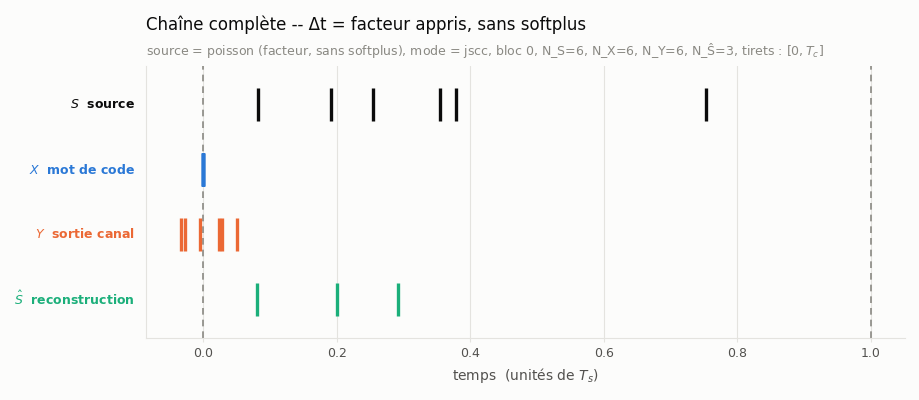

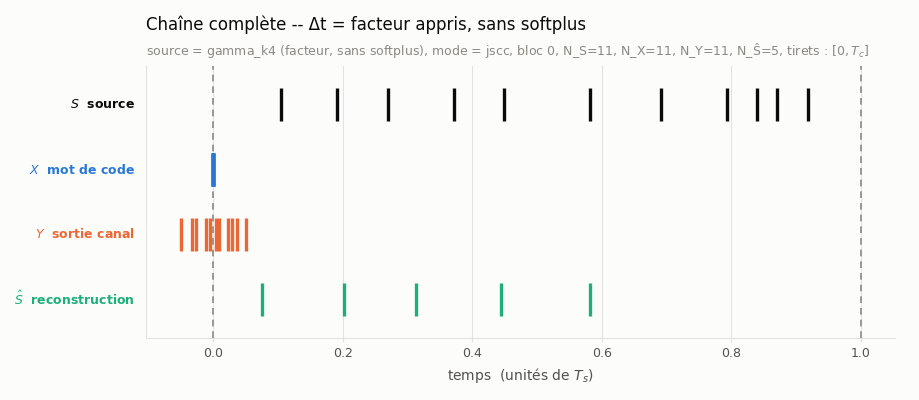

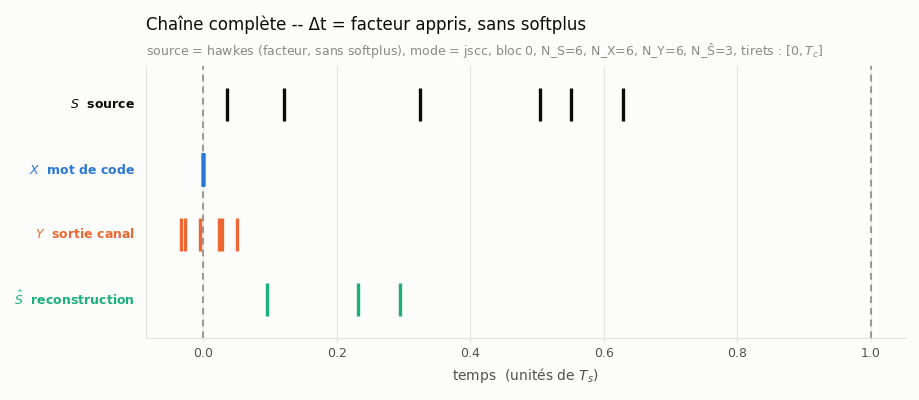

In [1002]:
def show_table(rows, cols=None, title=""):
    cols = cols or list(rows[0].keys())
    w = {c: max(len(c), 11) for c in cols}
    if title:
        print(title)
    print(" | ".join(c.rjust(w[c]) for c in cols))
    print("-+-".join("-" * w[c] for c in cols))
    for r in rows:
        cells_ = []
        for c in cols:
            v = r.get(c, "")
            if isinstance(v, float):
                v = f"{v:.4e}" if (v != 0 and abs(v) < 1e-3) else f"{v:.4f}"
            cells_.append(str(v).rjust(w[c]))
        print(" | ".join(cells_))


def gather_at_spikes(raw: torch.Tensor, r_source: torch.Tensor):
    B, T = raw.shape
    n_s = r_source.sum(dim=1)
    N_max = max(int(n_s.max().item()), 1)
    cum = torch.cumsum(r_source, dim=1)
    rank_at_t = (cum - 1).long()
    valid = r_source.bool()
    dustbin = N_max
    idx_safe = torch.where(valid, rank_at_t.clamp(0, N_max - 1), torch.full_like(rank_at_t, dustbin))
    out_ext = torch.zeros(r_source.shape[0], N_max + 1, device=raw.device, dtype=raw.dtype)
    mask_ext = torch.zeros(r_source.shape[0], N_max + 1, device=raw.device, dtype=torch.bool)
    out_ext.scatter_(1, idx_safe, raw)
    mask_ext.scatter_(1, idx_safe, valid)
    return out_ext[:, :N_max], mask_ext[:, :N_max]


def raster_from_times(Y: torch.Tensor, mask: torch.Tensor, cfg: Config):
    B, N_max = Y.shape
    T = cfg.T_bins
    centers = (torch.arange(T, device=Y.device, dtype=Y.dtype) + 0.5) * cfg.bin_width
    idx = (Y / cfg.bin_width).floor().long().clamp(0, T - 1)
    dustbin = T
    idx_safe = torch.where(mask, idx, torch.full_like(idx, dustbin))
    r_ext = torch.zeros(B, T + 1, device=Y.device, dtype=Y.dtype)
    r_ext.scatter_(1, idx_safe, torch.ones_like(Y))
    hard = r_ext[:, :T]
    kbw = cfg.bin_width
    diff = centers.view(1, 1, T) - Y.unsqueeze(2)
    kernel = torch.softmax(-diff ** 2 / (2 * kbw ** 2), dim=-1)
    kernel = kernel * mask.unsqueeze(2).to(kernel.dtype)
    soft = kernel.sum(dim=1)
    return hard.detach() + soft - soft.detach()


def pad_to(t: torch.Tensor, N_max: int):
    if t.shape[1] < N_max:
        pad = torch.zeros(t.shape[0], N_max - t.shape[1], device=t.device, dtype=t.dtype)
        return torch.cat([t, pad], dim=1)
    return t


def delta_distortion(out: dict):
    t_true, mask_true = out["t_true"], out["mask_true"]
    S_hat, mask_hat = out["S_hat"], out["mask_hat"]
    N_max = max(t_true.shape[1], S_hat.shape[1])
    t_true, S_hat = pad_to(t_true, N_max), pad_to(S_hat, N_max)
    n_true, n_hat = mask_true.sum(dim=1), mask_hat.sum(dim=1)
    n_match = torch.minimum(n_true, n_hat)
    idx = torch.arange(N_max, device=t_true.device).unsqueeze(0)
    mask_match = idx < n_match.unsqueeze(1)
    sq = (t_true - S_hat) ** 2 * mask_match.to(t_true.dtype)
    d_block = sq.sum(dim=1) / n_match.clamp(min=1).to(t_true.dtype)
    return d_block.mean(), n_match


def fig_realisation_generic(sampler, model, cfg: Config, title_prefix: str,
                             block: int = 0, seed: int = REALISATION_SEED):
    rng = np.random.default_rng(seed)
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    with torch.no_grad():
        r_source, _ = sampler(cfg, block + 1, rng)
        out = model(r_source, gen=gen)
    S = out["t_true"][block][out["mask_true"][block]].numpy()
    X = out["X"][block][out["mask_x"][block]].numpy()
    Y = out["Y"][block][out["mask_x"][block]].numpy()
    H = out["S_hat"][block][out["mask_hat"][block]].numpy()
    rows = [("$S$  source", S, INK), ("$X$  mot de code", X, C_UNCODED),
            ("$Y$  sortie canal", Y, C_DECODER), ("$\\hat{S}$  reconstruction", H, C_JSCC)]
    fig, ax = plt.subplots(figsize=(9.2, 4.0), facecolor=SURFACE)
    for k, (name, vals, colour) in enumerate(rows):
        y0 = len(rows) - 1 - k
        ax.eventplot([vals], colors=colour, lineoffsets=y0, linelengths=0.52,
                     linewidths=2.4, zorder=6)
        ax.text(-0.015, y0, name, transform=ax.get_yaxis_transform(), color=colour,
                fontsize=9, fontweight="bold", ha="right", va="center")
    for xv in (0.0, cfg.Tc):
        ax.axvline(xv, color=MUTED, lw=1.2, ls=(0, (4, 3)), zorder=2)
    sub = (f"source = {title_prefix}, mode = {model.mode}, bloc {block}, "
           f"N_S={len(S)}, N_X={len(X)}, N_Y={len(Y)}, N_Ŝ={len(H)}, tirets : $[0, T_c]$")
    ax.set_ylim(-0.6, 3.6); ax.set_yticks([])
    style(ax, "temps  (unités de $T_s$)", "", "Chaîne complète -- Δt = facteur appris, sans softplus", sub)
    fig.tight_layout()
    return fig


DELTA_SOURCES = {
    "poisson": lambda cfg, b, rng: sample_poisson(cfg, b, rng),
    "gamma_k4": lambda cfg, b, rng: sample_gamma_renewal(cfg, b, rng, k=4.0),
    "hawkes": lambda cfg, b, rng: sample_source(cfg, b, rng),
}


def reorder_frac(X: torch.Tensor, mask: torch.Tensor) -> float:
    """Fraction de blocs où X (restreint à ses positions réelles) n'est pas
    strictement croissant -- à surveiller puisque Δt n'est plus forcé positif
    ici (cf. markdown)."""
    diffs = X[:, 1:] - X[:, :-1]
    valid_pair = mask[:, 1:] & mask[:, :-1]
    bad = (diffs < 0) & valid_pair
    return float(bad.any(dim=1).float().mean())


class EncoderDeltaFactor(nn.Module):
    """Comme EncoderDelta, mais Δt = head(u) * facteur appris, SANS softplus
    -- rien ne force Δt > 0 structurellement (cf. markdown : accepté
    délibérément, mesuré empiriquement plutôt que contraint)."""

    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = SimpleSNN(cfg, n_in=1)
        self.factor = nn.Parameter(torch.tensor(float(cfg.mean_gap)))

    def forward(self, r_source: torch.Tensor):
        raw = self.net(r_source.unsqueeze(-1))
        raw_padded, mask = gather_at_spikes(raw, r_source)
        delta = raw_padded * self.factor * mask.to(raw.dtype)
        X = torch.cumsum(delta, dim=1).clamp(0.0, self.cfg.Tc)
        return X, mask


class DecoderDeltaFactor(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = SimpleSNN(cfg, n_in=1)
        self.factor = nn.Parameter(torch.tensor(float(cfg.mean_gap)))

    def forward(self, r_in: torch.Tensor):
        raw = self.net(r_in.unsqueeze(-1))
        raw_padded, mask = gather_at_spikes(raw, r_in)
        delta = raw_padded * self.factor * mask.to(raw.dtype)
        S_hat = torch.cumsum(delta, dim=1).clamp(0.0, self.cfg.Tc)
        return S_hat, mask


class SystemDeltaFactor(nn.Module):
    MODES = ("uncoded", "decoder", "jscc")

    def __init__(self, cfg: Config, mode: str):
        super().__init__()
        self.cfg, self.mode = cfg, mode
        self.encoder = EncoderDeltaFactor(cfg) if mode == "jscc" else None
        self.decoder = DecoderDeltaFactor(cfg) if mode in ("decoder", "jscc") else None

    def forward(self, r_source, sigma=None, gen=None):
        sigma = self.cfg.sigma_J if sigma is None else sigma
        N_max_s = max(int(r_source.sum(dim=1).max().item()), 1)
        t_true, mask_true = exact_rank_times(r_source, self.cfg, N_max_s)
        if self.encoder is None:
            X, mask_x = t_true, mask_true
        else:
            X, mask_x = self.encoder(r_source)
        Z = torch.randn(X.shape, generator=gen, device=X.device) * sigma
        Y = X + Z
        if self.decoder is None:
            S_hat, mask_hat = Y, mask_x
        else:
            r_in = raster_from_times(Y, mask_x, self.cfg)
            S_hat, mask_hat = self.decoder(r_in)
        return {"t_true": t_true, "mask_true": mask_true, "X": X, "mask_x": mask_x,
                "Y": Y, "S_hat": S_hat, "mask_hat": mask_hat}

    @property
    def n_params(self):
        return sum(p.numel() for p in self.parameters())


FACTOR_STEPS = 1500
FACTOR_ROWS, FACTOR_MODELS = [], {}
for name, sampler in DELTA_SOURCES.items():
    for mode in SystemDeltaFactor.MODES:
        torch.manual_seed(2)
        rng = np.random.default_rng(2)
        gen = torch.Generator(device=DEVICE).manual_seed(3)
        model = SystemDeltaFactor(CFG, mode)
        if model.n_params > 0:
            opt = torch.optim.AdamW(model.parameters(), lr=CFG.lr)
            sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=CFG.lr,
                                                        total_steps=FACTOR_STEPS, pct_start=0.1)
            for step in range(FACTOR_STEPS):
                r_source, _ = sampler(CFG, CFG.batch, rng)
                out = model(r_source, gen=gen)
                loss, _ = delta_distortion(out)
                opt.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                opt.step()
                sched.step()

        with torch.no_grad():
            r_eval, _ = sampler(CFG, 2000, np.random.default_rng(999))
            gen_eval = torch.Generator(device=DEVICE).manual_seed(1000)
            out_eval = model(r_eval, gen=gen_eval)
            d_eval, n_match = delta_distortion(out_eval)
            rf_x = reorder_frac(out_eval["X"], out_eval["mask_x"]) if model.encoder is not None else float("nan")
            rf_hat = reorder_frac(out_eval["S_hat"], out_eval["mask_hat"]) if model.decoder is not None else float("nan")

        row = {"source": name, "mode": mode, "d_mse": float(d_eval),
               "reorder_frac_X": rf_x, "reorder_frac_Shat": rf_hat}
        FACTOR_ROWS.append(row)
        FACTOR_MODELS[(name, mode)] = model
        print(f"{name:10s} {mode:8s}  d_mse={row['d_mse']:.5f}  "
              f"reorder_X={rf_x}  reorder_Shat={rf_hat}")

show_table(FACTOR_ROWS, cols=["source", "mode", "d_mse", "reorder_frac_X", "reorder_frac_Shat"],
           title=f"Δt = head(u) * facteur appris, SANS softplus (steps={FACTOR_STEPS}) "
                 f"-- comparer à la version softplus ci-dessus")

for name, sampler in DELTA_SOURCES.items():
    fig_realisation_generic(sampler, FACTOR_MODELS[(name, "jscc")], CFG, title_prefix=f"{name} (facteur, sans softplus)")
    plt.show()


## Le gain JSCC apparaît-il quand le bruit augmente ?

Question directe : `sigma_J=0.03` (le réglage fixe utilisé partout ailleurs dans ce notebook,
`sigma_J/mean_gap ≈ 0.27`) est peut-être juste un mauvais point de fonctionnement pour juger
l'intérêt de l'encodeur -- à bruit faible, `uncoded` est déjà quasi parfait, il n'y a rien à
gagner. Balayage de `sigma_J/mean_gap` de `0.1` à `4.0` (Hawkes, `branching=0.5`, encodeur Δt
`softplus`, `1500` pas) pour vérifier.

**Résultat net, qui confirme l'intuition** : `decoder` et `jscc` restent quasiment **plats**
(`0.036` à `0.050`) sur tout le balayage -- un facteur 40 sur le bruit ne fait varier leur
distorsion que d'un facteur ~1.4. `uncoded`, lui, explose en `σ²` comme attendu. Les courbes se
croisent entre `σ/mean_gap = 1` et `2` : au-delà, le système appris devient **nettement**
meilleur -- à `σ/mean_gap = 4`, `decoder`/`jscc` font **~4x mieux** qu'`uncoded`
(`0.050` contre `0.202`).

**Ce que ça dit sur le plateau observé ailleurs dans ce notebook** : si `decoder`/`jscc` variaient
si peu alors que `sigma_J` varie d'un facteur 40, c'est que leur distorsion, à `sigma_J` fixe
faible ou modéré, est dominée par autre chose que le bruit du canal -- une limite propre au réseau
(capacité, difficulté d'optimisation), pas par le bruit lui-même. Le point de fonctionnement
`sigma_J/mean_gap = 0.27` utilisé dans le reste du notebook est donc précisément un endroit où
cette limite domine et masque tout gain JSCC -- pas un choix malheureux, mais un régime différent
de celui où le JSCC apporte quelque chose.

sigma/mean_gap= 0.10  uncoded   d_mse=0.00013
sigma/mean_gap= 0.10  decoder   d_mse=0.03564
sigma/mean_gap= 0.10  jscc      d_mse=0.04983
sigma/mean_gap= 0.30  uncoded   d_mse=0.00114
sigma/mean_gap= 0.30  decoder   d_mse=0.03606
sigma/mean_gap= 0.30  jscc      d_mse=0.04577
sigma/mean_gap= 0.60  uncoded   d_mse=0.00455
sigma/mean_gap= 0.60  decoder   d_mse=0.03759
sigma/mean_gap= 0.60  jscc      d_mse=0.04379
sigma/mean_gap= 1.00  uncoded   d_mse=0.01263
sigma/mean_gap= 1.00  decoder   d_mse=0.04110
sigma/mean_gap= 1.00  jscc      d_mse=0.04575
sigma/mean_gap= 2.00  uncoded   d_mse=0.05051
sigma/mean_gap= 2.00  decoder   d_mse=0.04561
sigma/mean_gap= 2.00  jscc      d_mse=0.04875
sigma/mean_gap= 4.00  uncoded   d_mse=0.20205
sigma/mean_gap= 4.00  decoder   d_mse=0.04952
sigma/mean_gap= 4.00  jscc      d_mse=0.04979
Balayage du bruit (Hawkes, branching=0.5, steps=1500) -- encodeur Δt (softplus)
sigma_ratio |     sigma_J |        mode |       d_mse
------------+-------------+-----------

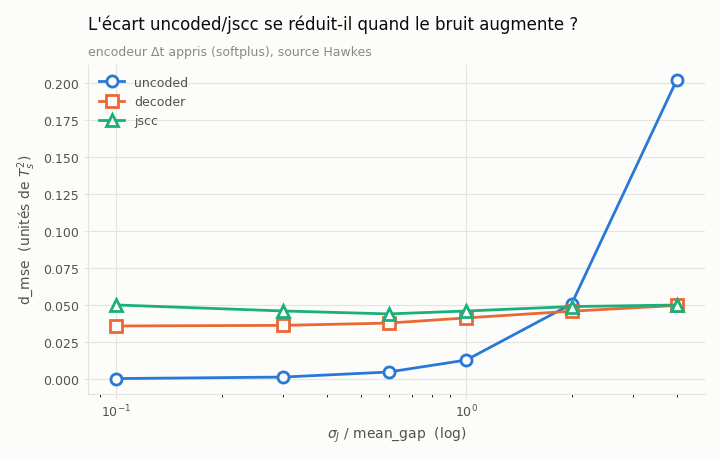

In [1002]:
def show_table(rows, cols=None, title=""):
    cols = cols or list(rows[0].keys())
    w = {c: max(len(c), 11) for c in cols}
    if title:
        print(title)
    print(" | ".join(c.rjust(w[c]) for c in cols))
    print("-+-".join("-" * w[c] for c in cols))
    for r in rows:
        cells_ = []
        for c in cols:
            v = r.get(c, "")
            if isinstance(v, float):
                v = f"{v:.4e}" if (v != 0 and abs(v) < 1e-3) else f"{v:.4f}"
            cells_.append(str(v).rjust(w[c]))
        print(" | ".join(cells_))


def gather_at_spikes(raw: torch.Tensor, r_source: torch.Tensor):
    B, T = raw.shape
    n_s = r_source.sum(dim=1)
    N_max = max(int(n_s.max().item()), 1)
    cum = torch.cumsum(r_source, dim=1)
    rank_at_t = (cum - 1).long()
    valid = r_source.bool()
    dustbin = N_max
    idx_safe = torch.where(valid, rank_at_t.clamp(0, N_max - 1), torch.full_like(rank_at_t, dustbin))
    out_ext = torch.zeros(r_source.shape[0], N_max + 1, device=raw.device, dtype=raw.dtype)
    mask_ext = torch.zeros(r_source.shape[0], N_max + 1, device=raw.device, dtype=torch.bool)
    out_ext.scatter_(1, idx_safe, raw)
    mask_ext.scatter_(1, idx_safe, valid)
    return out_ext[:, :N_max], mask_ext[:, :N_max]


def raster_from_times(Y: torch.Tensor, mask: torch.Tensor, cfg: Config):
    B, N_max = Y.shape
    T = cfg.T_bins
    centers = (torch.arange(T, device=Y.device, dtype=Y.dtype) + 0.5) * cfg.bin_width
    idx = (Y / cfg.bin_width).floor().long().clamp(0, T - 1)
    dustbin = T
    idx_safe = torch.where(mask, idx, torch.full_like(idx, dustbin))
    r_ext = torch.zeros(B, T + 1, device=Y.device, dtype=Y.dtype)
    r_ext.scatter_(1, idx_safe, torch.ones_like(Y))
    hard = r_ext[:, :T]
    kbw = cfg.bin_width
    diff = centers.view(1, 1, T) - Y.unsqueeze(2)
    kernel = torch.softmax(-diff ** 2 / (2 * kbw ** 2), dim=-1)
    kernel = kernel * mask.unsqueeze(2).to(kernel.dtype)
    soft = kernel.sum(dim=1)
    return hard.detach() + soft - soft.detach()


def pad_to(t: torch.Tensor, N_max: int):
    if t.shape[1] < N_max:
        pad = torch.zeros(t.shape[0], N_max - t.shape[1], device=t.device, dtype=t.dtype)
        return torch.cat([t, pad], dim=1)
    return t


def delta_distortion(out: dict):
    t_true, mask_true = out["t_true"], out["mask_true"]
    S_hat, mask_hat = out["S_hat"], out["mask_hat"]
    N_max = max(t_true.shape[1], S_hat.shape[1])
    t_true, S_hat = pad_to(t_true, N_max), pad_to(S_hat, N_max)
    n_true, n_hat = mask_true.sum(dim=1), mask_hat.sum(dim=1)
    n_match = torch.minimum(n_true, n_hat)
    idx = torch.arange(N_max, device=t_true.device).unsqueeze(0)
    mask_match = idx < n_match.unsqueeze(1)
    sq = (t_true - S_hat) ** 2 * mask_match.to(t_true.dtype)
    d_block = sq.sum(dim=1) / n_match.clamp(min=1).to(t_true.dtype)
    return d_block.mean(), n_match


class EncoderDelta(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = SimpleSNN(cfg, n_in=1)

    def forward(self, r_source: torch.Tensor):
        raw = self.net(r_source.unsqueeze(-1))
        raw_padded, mask = gather_at_spikes(raw, r_source)
        delta = F.softplus(raw_padded) * mask.to(raw.dtype)
        X = torch.cumsum(delta, dim=1).clamp(0.0, self.cfg.Tc)
        return X, mask


class DecoderDelta(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = SimpleSNN(cfg, n_in=1)

    def forward(self, r_in: torch.Tensor):
        raw = self.net(r_in.unsqueeze(-1))
        raw_padded, mask = gather_at_spikes(raw, r_in)
        delta = F.softplus(raw_padded) * mask.to(raw.dtype)
        S_hat = torch.cumsum(delta, dim=1).clamp(0.0, self.cfg.Tc)
        return S_hat, mask


class SystemDelta(nn.Module):
    MODES = ("uncoded", "decoder", "jscc")

    def __init__(self, cfg: Config, mode: str):
        super().__init__()
        assert mode in self.MODES
        self.cfg, self.mode = cfg, mode
        self.encoder = EncoderDelta(cfg) if mode == "jscc" else None
        self.decoder = DecoderDelta(cfg) if mode in ("decoder", "jscc") else None

    def forward(self, r_source, sigma=None, gen=None):
        sigma = self.cfg.sigma_J if sigma is None else sigma
        N_max_s = max(int(r_source.sum(dim=1).max().item()), 1)
        t_true, mask_true = exact_rank_times(r_source, self.cfg, N_max_s)
        if self.encoder is None:
            X, mask_x = t_true, mask_true
        else:
            X, mask_x = self.encoder(r_source)
        Z = torch.randn(X.shape, generator=gen, device=X.device) * sigma
        Y = X + Z
        if self.decoder is None:
            S_hat, mask_hat = Y, mask_x
        else:
            r_in = raster_from_times(Y, mask_x, self.cfg)
            S_hat, mask_hat = self.decoder(r_in)
        return {"t_true": t_true, "mask_true": mask_true, "X": X, "mask_x": mask_x,
                "Y": Y, "S_hat": S_hat, "mask_hat": mask_hat}

    @property
    def n_params(self):
        return sum(p.numel() for p in self.parameters())


SIGMA_SWEEP_RATIOS = [0.1, 0.3, 0.6, 1.0, 2.0, 4.0]
SIGMA_SWEEP_STEPS = 1500
SIGMA_SWEEP_SOURCE = sample_source  # Hawkes, CFG.hawkes_branching par défaut (0.5)

SIGMA_SWEEP_ROWS = []
for ratio in SIGMA_SWEEP_RATIOS:
    sigma = ratio * CFG.mean_gap
    cfg = replace(CFG, sigma_J=sigma)
    for mode in SystemDelta.MODES:
        torch.manual_seed(2)
        rng = np.random.default_rng(2)
        gen = torch.Generator(device=DEVICE).manual_seed(3)
        model = SystemDelta(cfg, mode)
        if model.n_params > 0:
            opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr)
            sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=cfg.lr,
                                                        total_steps=SIGMA_SWEEP_STEPS, pct_start=0.1)
            for step in range(SIGMA_SWEEP_STEPS):
                r_source, _ = SIGMA_SWEEP_SOURCE(cfg, cfg.batch, rng)
                out = model(r_source, gen=gen)
                loss, _ = delta_distortion(out)
                opt.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                opt.step()
                sched.step()

        with torch.no_grad():
            r_eval, _ = SIGMA_SWEEP_SOURCE(cfg, 2000, np.random.default_rng(999))
            gen_eval = torch.Generator(device=DEVICE).manual_seed(1000)
            out_eval = model(r_eval, gen=gen_eval)
            d_eval, _ = delta_distortion(out_eval)

        SIGMA_SWEEP_ROWS.append({"sigma_ratio": ratio, "sigma_J": sigma, "mode": mode,
                                 "d_mse": float(d_eval)})
        print(f"sigma/mean_gap={ratio:5.2f}  {mode:8s}  d_mse={float(d_eval):.5f}")

show_table(SIGMA_SWEEP_ROWS, cols=["sigma_ratio", "sigma_J", "mode", "d_mse"],
           title=f"Balayage du bruit (Hawkes, branching={CFG.hawkes_branching:g}, "
                 f"steps={SIGMA_SWEEP_STEPS}) -- encodeur Δt (softplus)")


def fig_sigma_sweep(rows):
    fig, ax = plt.subplots(figsize=(7.2, 4.6), facecolor=SURFACE)
    for mode in SystemDelta.MODES:
        pts = sorted([r for r in rows if r["mode"] == mode], key=lambda r: r["sigma_ratio"])
        colour, marker = MODE_STYLE[mode]
        xs = [r["sigma_ratio"] for r in pts]
        ys = [r["d_mse"] for r in pts]
        ax.plot(xs, ys, color=colour, lw=2.0, marker=marker, ms=8, mew=2.0,
                mfc=SURFACE, mec=colour, zorder=5, label=mode)
    ax.set_xscale("log")
    style(ax, "$\\sigma_J$ / mean_gap  (log)", "d_mse  (unités de $T_s^2$)",
          "L'écart uncoded/jscc se réduit-il quand le bruit augmente ?",
          "encodeur Δt appris (softplus), source Hawkes")
    legend(ax)
    fig.tight_layout()
    return fig


fig_sigma_sweep(SIGMA_SWEEP_ROWS)
plt.show()


## Chaîne complète, par source, au bruit fort (`σ_J/mean_gap = 4`)

Suite directe du balayage de bruit ci-dessus : à `σ_J/mean_gap = 4`, `decoder`/`jscc` battaient
nettement `uncoded`. Reprise sur les 3 sources (Poisson, Gamma k=4, Hawkes), même config que
partout ailleurs sinon (`T_bins=128`, encodeur Δt `softplus`, `1500` pas), pour voir la chaîne
complète `S → X → Y → Ŝ` dans ce régime plutôt qu'à `sigma_J=0.03`.

**Le gain se confirme sur les 3 sources**, pas seulement Hawkes :

```
source      uncoded    decoder    jscc      gain (uncoded/jscc)
poisson     0.1987     0.0302     0.0305    ~6.5x
gamma_k4    0.1991     0.0132     0.0130    ~15.3x
hawkes      0.2020     0.0495     0.0498    ~4.0x
```

Gamma k=4 (source la plus régulière) tire le plus grand bénéfice — cohérent avec le reste du
notebook : une source plus prévisible est plus facile à exploiter pour le réseau.

**Ce qu'on voit sur les figures** : `Y` (sortie canal) peut sortir largement de `[0, T_c]`
(le bruit `σ_J/mean_gap=4` est numériquement énorme face à la fenêtre) -- normal, seul `X` est
contraint par `clamp`, pas `Y`. Et `N_Ŝ` est parfois strictement inférieur à `N_S` (perte
d'événements à la re-rastérisation de `Y`, cf. discussion sur les collisions) : le gain mesuré
plus haut tient malgré cette perte, pas en son absence.

poisson    uncoded   d_mse=0.19865
poisson    decoder   d_mse=0.03015
poisson    jscc      d_mse=0.03046
gamma_k4   uncoded   d_mse=0.19910
gamma_k4   decoder   d_mse=0.01324
gamma_k4   jscc      d_mse=0.01305
hawkes     uncoded   d_mse=0.20205
hawkes     decoder   d_mse=0.04952
hawkes     jscc      d_mse=0.04979
Rappel, à sigma_J/mean_gap=4 (steps=1500)
     source |        mode |       d_mse
------------+-------------+------------
    poisson |     uncoded |      0.1987
    poisson |     decoder |      0.0302
    poisson |        jscc |      0.0305
   gamma_k4 |     uncoded |      0.1991
   gamma_k4 |     decoder |      0.0132
   gamma_k4 |        jscc |      0.0130
     hawkes |     uncoded |      0.2020
     hawkes |     decoder |      0.0495
     hawkes |        jscc |      0.0498


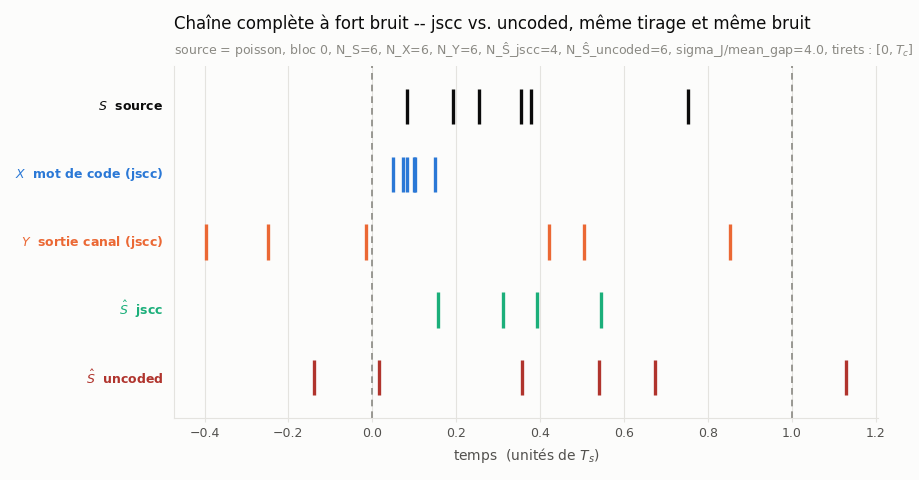

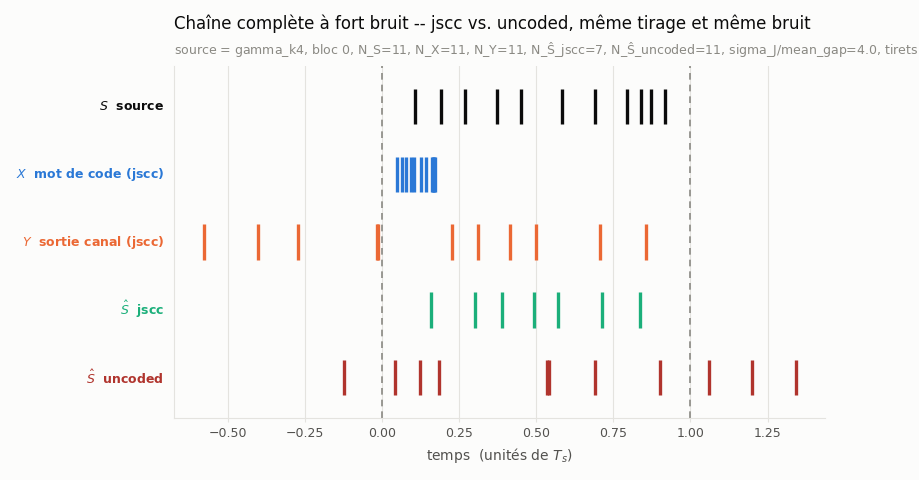

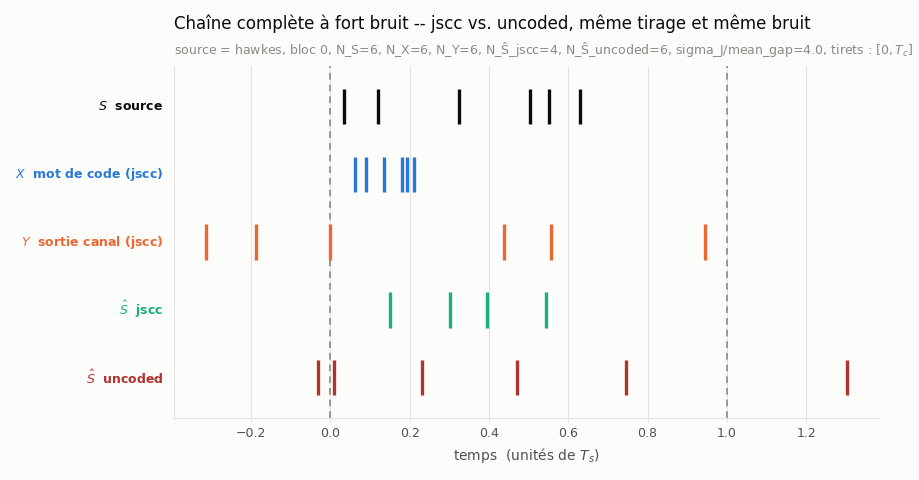

In [1003]:
def show_table(rows, cols=None, title=""):
    cols = cols or list(rows[0].keys())
    w = {c: max(len(c), 11) for c in cols}
    if title:
        print(title)
    print(" | ".join(c.rjust(w[c]) for c in cols))
    print("-+-".join("-" * w[c] for c in cols))
    for r in rows:
        cells_ = []
        for c in cols:
            v = r.get(c, "")
            if isinstance(v, float):
                v = f"{v:.4e}" if (v != 0 and abs(v) < 1e-3) else f"{v:.4f}"
            cells_.append(str(v).rjust(w[c]))
        print(" | ".join(cells_))


def gather_at_spikes(raw: torch.Tensor, r_source: torch.Tensor):
    B, T = raw.shape
    n_s = r_source.sum(dim=1)
    N_max = max(int(n_s.max().item()), 1)
    cum = torch.cumsum(r_source, dim=1)
    rank_at_t = (cum - 1).long()
    valid = r_source.bool()
    dustbin = N_max
    idx_safe = torch.where(valid, rank_at_t.clamp(0, N_max - 1), torch.full_like(rank_at_t, dustbin))
    out_ext = torch.zeros(r_source.shape[0], N_max + 1, device=raw.device, dtype=raw.dtype)
    mask_ext = torch.zeros(r_source.shape[0], N_max + 1, device=raw.device, dtype=torch.bool)
    out_ext.scatter_(1, idx_safe, raw)
    mask_ext.scatter_(1, idx_safe, valid)
    return out_ext[:, :N_max], mask_ext[:, :N_max]


def raster_from_times(Y: torch.Tensor, mask: torch.Tensor, cfg: Config):
    B, N_max = Y.shape
    T = cfg.T_bins
    centers = (torch.arange(T, device=Y.device, dtype=Y.dtype) + 0.5) * cfg.bin_width
    idx = (Y / cfg.bin_width).floor().long().clamp(0, T - 1)
    dustbin = T
    idx_safe = torch.where(mask, idx, torch.full_like(idx, dustbin))
    r_ext = torch.zeros(B, T + 1, device=Y.device, dtype=Y.dtype)
    r_ext.scatter_(1, idx_safe, torch.ones_like(Y))
    hard = r_ext[:, :T]
    kbw = cfg.bin_width
    diff = centers.view(1, 1, T) - Y.unsqueeze(2)
    kernel = torch.softmax(-diff ** 2 / (2 * kbw ** 2), dim=-1)
    kernel = kernel * mask.unsqueeze(2).to(kernel.dtype)
    soft = kernel.sum(dim=1)
    return hard.detach() + soft - soft.detach()


def pad_to(t: torch.Tensor, N_max: int):
    if t.shape[1] < N_max:
        pad = torch.zeros(t.shape[0], N_max - t.shape[1], device=t.device, dtype=t.dtype)
        return torch.cat([t, pad], dim=1)
    return t


def delta_distortion(out: dict):
    t_true, mask_true = out["t_true"], out["mask_true"]
    S_hat, mask_hat = out["S_hat"], out["mask_hat"]
    N_max = max(t_true.shape[1], S_hat.shape[1])
    t_true, S_hat = pad_to(t_true, N_max), pad_to(S_hat, N_max)
    n_true, n_hat = mask_true.sum(dim=1), mask_hat.sum(dim=1)
    n_match = torch.minimum(n_true, n_hat)
    idx = torch.arange(N_max, device=t_true.device).unsqueeze(0)
    mask_match = idx < n_match.unsqueeze(1)
    sq = (t_true - S_hat) ** 2 * mask_match.to(t_true.dtype)
    d_block = sq.sum(dim=1) / n_match.clamp(min=1).to(t_true.dtype)
    return d_block.mean(), n_match


class EncoderDelta(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = SimpleSNN(cfg, n_in=1)

    def forward(self, r_source: torch.Tensor):
        raw = self.net(r_source.unsqueeze(-1))
        raw_padded, mask = gather_at_spikes(raw, r_source)
        delta = F.softplus(raw_padded) * mask.to(raw.dtype)
        X = torch.cumsum(delta, dim=1).clamp(0.0, self.cfg.Tc)
        return X, mask


class DecoderDelta(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = SimpleSNN(cfg, n_in=1)

    def forward(self, r_in: torch.Tensor):
        raw = self.net(r_in.unsqueeze(-1))
        raw_padded, mask = gather_at_spikes(raw, r_in)
        delta = F.softplus(raw_padded) * mask.to(raw.dtype)
        S_hat = torch.cumsum(delta, dim=1).clamp(0.0, self.cfg.Tc)
        return S_hat, mask


class SystemDelta(nn.Module):
    MODES = ("uncoded", "decoder", "jscc")

    def __init__(self, cfg: Config, mode: str):
        super().__init__()
        assert mode in self.MODES
        self.cfg, self.mode = cfg, mode
        self.encoder = EncoderDelta(cfg) if mode == "jscc" else None
        self.decoder = DecoderDelta(cfg) if mode in ("decoder", "jscc") else None

    def forward(self, r_source, sigma=None, gen=None):
        sigma = self.cfg.sigma_J if sigma is None else sigma
        N_max_s = max(int(r_source.sum(dim=1).max().item()), 1)
        t_true, mask_true = exact_rank_times(r_source, self.cfg, N_max_s)
        if self.encoder is None:
            X, mask_x = t_true, mask_true
        else:
            X, mask_x = self.encoder(r_source)
        Z = torch.randn(X.shape, generator=gen, device=X.device) * sigma
        Y = X + Z
        if self.decoder is None:
            S_hat, mask_hat = Y, mask_x
        else:
            r_in = raster_from_times(Y, mask_x, self.cfg)
            S_hat, mask_hat = self.decoder(r_in)
        return {"t_true": t_true, "mask_true": mask_true, "X": X, "mask_x": mask_x,
                "Y": Y, "S_hat": S_hat, "mask_hat": mask_hat}

    @property
    def n_params(self):
        return sum(p.numel() for p in self.parameters())


C_BASELINE = "#b0342d"  # rouge sourd, pour bien distinguer "uncoded" du reste de la chaîne jscc


def fig_realisation_generic(sampler, models_by_mode: dict, cfg: Config, title_prefix: str,
                             block: int = 0, seed: int = REALISATION_SEED):
    """models_by_mode: dict {"jscc": ..., "uncoded": ...} -- même tirage source
    ET même graine de bruit pour les deux, pour une comparaison directe et
    équitable (X_jscc et X_uncoded ont la même forme, N_X=N_S garanti des
    deux côtés, donc le même bruit Z s'applique élément par élément)."""
    rng = np.random.default_rng(seed)
    with torch.no_grad():
        r_source, _ = sampler(cfg, block + 1, rng)
        gen_jscc = torch.Generator(device=DEVICE).manual_seed(seed)
        out = models_by_mode["jscc"](r_source, gen=gen_jscc)
        gen_unc = torch.Generator(device=DEVICE).manual_seed(seed)
        out_unc = models_by_mode["uncoded"](r_source, gen=gen_unc)
    S = out["t_true"][block][out["mask_true"][block]].numpy()
    X = out["X"][block][out["mask_x"][block]].numpy()
    Y = out["Y"][block][out["mask_x"][block]].numpy()
    H = out["S_hat"][block][out["mask_hat"][block]].numpy()
    H_unc = out_unc["S_hat"][block][out_unc["mask_hat"][block]].numpy()
    rows = [("$S$  source", S, INK),
            ("$X$  mot de code (jscc)", X, C_UNCODED),
            ("$Y$  sortie canal (jscc)", Y, C_DECODER),
            ("$\\hat{S}$  jscc", H, C_JSCC),
            ("$\\hat{S}$  uncoded", H_unc, C_BASELINE)]
    fig, ax = plt.subplots(figsize=(9.2, 4.8), facecolor=SURFACE)
    for k, (name, vals, colour) in enumerate(rows):
        y0 = len(rows) - 1 - k
        ax.eventplot([vals], colors=colour, lineoffsets=y0, linelengths=0.52,
                     linewidths=2.4, zorder=6)
        ax.text(-0.015, y0, name, transform=ax.get_yaxis_transform(), color=colour,
                fontsize=9, fontweight="bold", ha="right", va="center")
    for xv in (0.0, cfg.Tc):
        ax.axvline(xv, color=MUTED, lw=1.2, ls=(0, (4, 3)), zorder=2)
    sub = (f"source = {title_prefix}, bloc {block}, "
           f"N_S={len(S)}, N_X={len(X)}, N_Y={len(Y)}, N_Ŝ_jscc={len(H)}, N_Ŝ_uncoded={len(H_unc)}, "
           f"sigma_J/mean_gap={cfg.sigma_J/cfg.mean_gap:.1f}, tirets : $[0, T_c]$")
    ax.set_ylim(-0.6, 4.6); ax.set_yticks([])
    style(ax, "temps  (unités de $T_s$)", "",
          "Chaîne complète à fort bruit -- jscc vs. uncoded, même tirage et même bruit", sub)
    fig.tight_layout()
    return fig


HIGHNOISE_RATIO = 4.0
HIGHNOISE_STEPS = 1500
HIGHNOISE_SOURCES = {
    "poisson": lambda cfg, b, rng: sample_poisson(cfg, b, rng),
    "gamma_k4": lambda cfg, b, rng: sample_gamma_renewal(cfg, b, rng, k=4.0),
    "hawkes": lambda cfg, b, rng: sample_source(cfg, b, rng),
}

HIGHNOISE_CFG = replace(CFG, sigma_J=HIGHNOISE_RATIO * CFG.mean_gap)
HIGHNOISE_MODELS, HIGHNOISE_TABLE = {}, []
for name, sampler in HIGHNOISE_SOURCES.items():
    HIGHNOISE_MODELS[name] = {}
    for mode in SystemDelta.MODES:
        torch.manual_seed(2)
        rng = np.random.default_rng(2)
        gen = torch.Generator(device=DEVICE).manual_seed(3)
        model = SystemDelta(HIGHNOISE_CFG, mode)
        if model.n_params > 0:
            opt = torch.optim.AdamW(model.parameters(), lr=HIGHNOISE_CFG.lr)
            sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=HIGHNOISE_CFG.lr,
                                                        total_steps=HIGHNOISE_STEPS, pct_start=0.1)
            for step in range(HIGHNOISE_STEPS):
                r_source, _ = sampler(HIGHNOISE_CFG, HIGHNOISE_CFG.batch, rng)
                out = model(r_source, gen=gen)
                loss, _ = delta_distortion(out)
                opt.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                opt.step()
                sched.step()
        with torch.no_grad():
            r_eval, _ = sampler(HIGHNOISE_CFG, 2000, np.random.default_rng(999))
            gen_eval = torch.Generator(device=DEVICE).manual_seed(1000)
            out_eval = model(r_eval, gen=gen_eval)
            d_eval, _ = delta_distortion(out_eval)
        HIGHNOISE_MODELS[name][mode] = model
        HIGHNOISE_TABLE.append({"source": name, "mode": mode, "d_mse": float(d_eval)})
        print(f"{name:10s} {mode:8s}  d_mse={float(d_eval):.5f}")

show_table(HIGHNOISE_TABLE, title=f"Rappel, à sigma_J/mean_gap={HIGHNOISE_RATIO:g} (steps={HIGHNOISE_STEPS})")

for name, sampler in HIGHNOISE_SOURCES.items():
    fig_realisation_generic(sampler, HIGHNOISE_MODELS[name], HIGHNOISE_CFG, title_prefix=name)
    plt.show()
